# Exploratory Data Analysis

## Preliminaries

In [1]:
# Load libraries
# =================================================================================

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Load and merge data
# =================================================================================

train = pd.read_csv('../data/raw/train.csv', sep='|')
items = pd.read_csv('../data/raw/items.csv', sep='|')

df = train.merge(items, 
                   on='pid', 
                   how='left',
                   validate="m:1")

In [3]:
# Define features and target
# =================================================================================

target_variable = 'order'

num_features = ['competitorPrice',
                'price',
                'revenue',
                'rrp']

cat_features = ['lineID',
                'day',
                'pid',
                'adFlag',
                'availability',
                'click',
                'basket',
                'manufacturer',
                'group',
                'content',
                'unit',
                'pharmForm',
                'genericProduct',
                'salesIndex',
                'category',
                'campaignIndex']

## Initial Data Analysis

In [4]:
# Display data
# =================================================================================

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df.head(20)

,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,revenue,manufacturer,group,content,unit,pharmForm,genericProduct,salesIndex,category,campaignIndex,rrp
0,1,1,6570,0,2,14.60,1,0,0,16.89,0.00,255,2FOI,50,ML,TRO,0,40,193.0,NaN,18.25
1,2,1,14922,1,1,8.57,0,1,0,8.75,0.00,18,1COJ0FIK,50,ST,TAB,1,40,66.0,C,18.81
2,3,1,16382,0,1,14.77,0,1,0,16.06,0.00,41,22OI7,2X50,ML,STI,0,53,40.0,NaN,18.48
3,4,1,1145,1,1,6.59,0,0,1,6.55,6.55,52,18OZ00IS,60,G,GEL,0,40,25.0,NaN,9.31
4,5,1,3394,0,1,4.39,0,0,1,4.14,4.14,90,20OI0,25X2,ST,KOM,0,53,14.0,NaN,8.13
5,6,1,3661,0,1,13.66,0,0,1,10.03,10.03,90,13OX06,1000,ML,LOE,0,52,127.0,NaN,21.60
6,7,1,3856,1,1,3.03,0,0,1,3.58,3.58,84,13OK0FOK,20,G,SAL,0,40,90.0,NaN,5.62
7,8,1,16963,0,1,8.78,1,0,0,8.75,0.00,89,22OI3,100,ML,SAL,0,53,8.0,NaN,11.62
8,9,1,14560,0,1,10.84,1,0,0,12.04,0.00,891,22OI3,50,ML,CRE,0,53,8.0,NaN,14.19
9,10,1,4853,1,1,9.12,1,0,0,8.75,0.00,590,13OX04OZ,100,G,SAL,0,40,90.0,NaN,14.25


In [5]:
# Display data info
# =================================================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2756003 entries, 0 to 2756002
Data columns (total 21 columns):
 #   Column           Dtype  
---  ------           -----  
 0   lineID           int64  
 1   day              int64  
 2   pid              int64  
 3   adFlag           int64  
 4   availability     int64  
 5   competitorPrice  float64
 6   click            int64  
 7   basket           int64  
 8   order            int64  
 9   price            float64
 10  revenue          float64
 11  manufacturer     int64  
 12  group            str    
 13  content          str    
 14  unit             str    
 15  pharmForm        str    
 16  genericProduct   int64  
 17  salesIndex       int64  
 18  category         float64
 19  campaignIndex    str    
 20  rrp              float64
dtypes: float64(5), int64(11), str(5)
memory usage: 441.6 MB


In [6]:
# Check for missing values
# =================================================================================

df.isnull().sum()

lineID                   0
day                      0
pid                      0
adFlag                   0
availability             0
competitorPrice     100687
click                    0
basket                   0
order                    0
price                    0
revenue                  0
manufacturer             0
group                    0
content                  0
unit                     0
pharmForm           194124
genericProduct           0
salesIndex               0
category             87394
campaignIndex      2287968
rrp                      0
dtype: int64

In [7]:
# Check for duplicates
# =================================================================================

df.duplicated().sum()

np.int64(0)

In [8]:
# Check for unique values in each column
# =================================================================================

df.nunique()

lineID             2756003
day                     92
pid                  21928
adFlag                   2
availability             4
competitorPrice       4992
click                    2
basket                   2
order                    2
price                 7475
revenue               7520
manufacturer          1065
group                  533
content                548
unit                     8
pharmForm              278
genericProduct           2
salesIndex               4
category               409
campaignIndex            3
rrp                   3282
dtype: int64

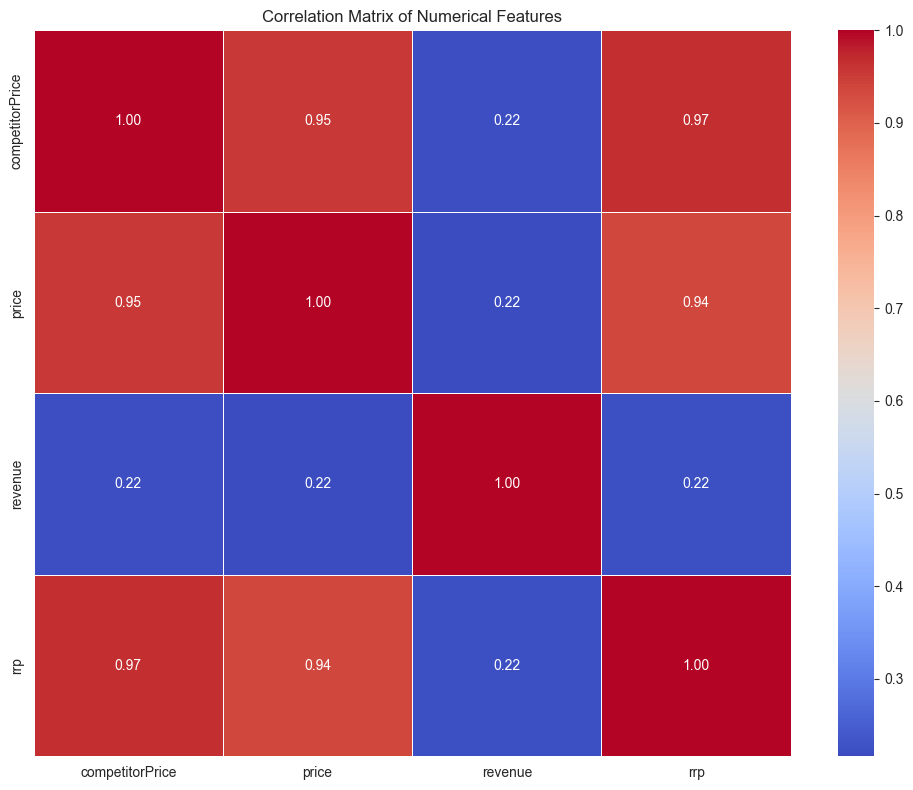

In [ ]:
# Correlation analysis
# =================================================================================

# Numbers
correlation_matrix = df[num_features].corr(method='pearson')
correlation_matrix.to_csv('../data/processed/EDA/correlation_matrix.csv')
print(correlation_matrix)

# Visualization of correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig('../data/processed/EDA/correlation_matrix.png')
plt.show()

In [10]:
# Correlation of features with target variable
# =================================================================================

df.corr(numeric_only=True)['order'].sort_values(ascending=False)

order              1.000000
revenue            0.624785
adFlag             0.104110
genericProduct     0.094414
category          -0.022645
pid               -0.036142
rrp               -0.061336
manufacturer      -0.065678
lineID            -0.072321
salesIndex        -0.075476
competitorPrice   -0.076286
day               -0.077351
price             -0.080649
availability      -0.089054
basket            -0.265211
click             -0.681058
Name: order, dtype: float64

## Further Data Analysis

### Target Variable

#### ***Order***

         count  percentage
order                     
0      2050913       74.42
1       705090       25.58


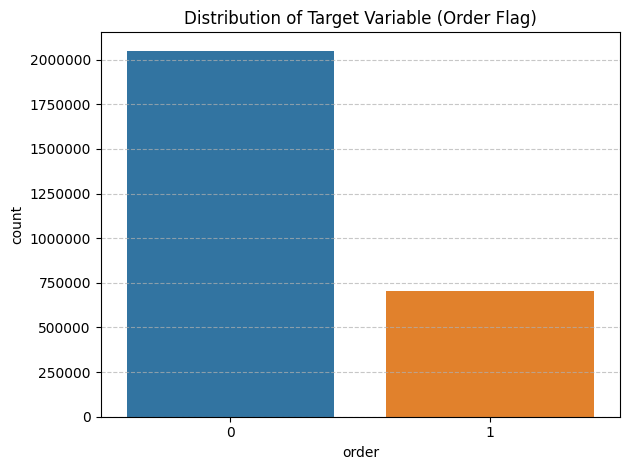

In [11]:
# Distribution of target variable
# =================================================================================

# Numbers
order_counts = df['order'].value_counts()
order_percentages = (df['order'].value_counts(normalize=True) * 100).round(2)
order_EDA = pd.DataFrame({'count': order_counts, 'percentage': order_percentages})
order_EDA.to_csv('../data/processed/EDA/order.csv', index=True)
print(order_EDA)

# Visualization
plot = sns.countplot(x="order", hue="order", data=df)
if plot.legend_ is not None:
    plot.legend_.remove()
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Target Variable (Order Flag)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().xaxis.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/EDA/order.png')
plt.show()

### Funnel Analysis

 stage   click  basket  order   total
 click 1582827  468086 705090 2756003
basket       0  468086 705090 1173176
 order       0       0 705090  705090


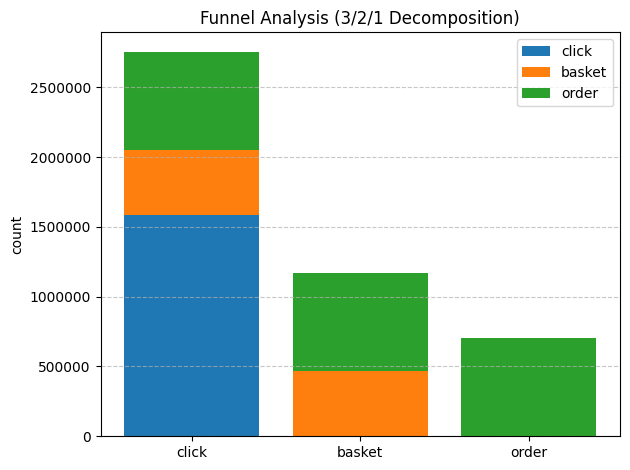

In [12]:
# Funnel analysis (3/2/1 Decomposition)
# =================================================================================

# Numbers
STAGES = ["click", "basket", "order"]
c, b, o = df[STAGES].sum().astype(int)

funnel_df = pd.DataFrame({
    "stage":  STAGES,
    "click":  [c, 0, 0],
    "basket": [b, b, 0],
    "order":  [o, o, o],
})
funnel_df["total"] = funnel_df[["click", "basket", "order"]].sum(axis=1)
funnel_df.to_csv('../data/processed/EDA/funnel_analysis.csv', index=False)
print(funnel_df.to_string(index=False))

# Visualization
colors = plt.cm.tab10.colors
bottoms = np.zeros(3)
for i, col in enumerate(STAGES):
    plt.bar(STAGES, funnel_df[col], bottom=bottoms, label=col, color=colors[i])
    bottoms += funnel_df[col].values
plt.gca().yaxis.get_major_formatter().set_scientific(False)
plt.title("Funnel Analysis (3/2/1 Decomposition)")
plt.ylabel("count")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().xaxis.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/EDA/funnel_analysis.png')
plt.show()

#### ***Basket***

        total_count  total_percentage  order_0_count  order_1_count  \
basket                                                                
0           2287917             83.02        1582827         705090   
1            468086             16.98         468086              0   

        order_0_percentage  order_1_percentage  
basket                                          
0                    69.18               30.82  
1                   100.00                0.00  


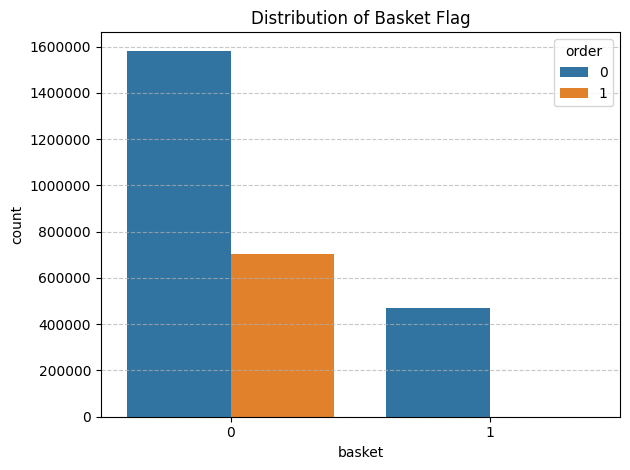

In [13]:
# Distribution of basket flag
# =================================================================================

# Numbers
basket_counts = df['basket'].value_counts()
basket_percentages = (df['basket'].value_counts(normalize=True) * 100).round(2)
basket_order_ct = pd.crosstab(df['basket'], df['order'])
basket_order_ct_pct = (pd.crosstab(df['basket'], df['order'], normalize='index') * 100).round(2)
basket_EDA_df = pd.DataFrame({
    'total_count': basket_counts,
    'total_percentage': basket_percentages,
    'order_0_count': basket_order_ct[0],
    'order_1_count': basket_order_ct[1],
    'order_0_percentage': basket_order_ct_pct[0],
    'order_1_percentage': basket_order_ct_pct[1]
})
print(basket_EDA_df)
basket_EDA_df.to_csv('../data/processed/EDA/basket.csv', index=True)

# Visualization
plot = sns.countplot(x="basket", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Basket Flag")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().xaxis.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/EDA/basket.png')
plt.show()

#### ***Click***

       total_count  total_percentage  order_0_count  order_1_count  \
click                                                                
0          1173176             42.57         468086         705090   
1          1582827             57.43        1582827              0   

       order_0_percentage  order_1_percentage  
click                                          
0                    39.9                60.1  
1                   100.0                 0.0  


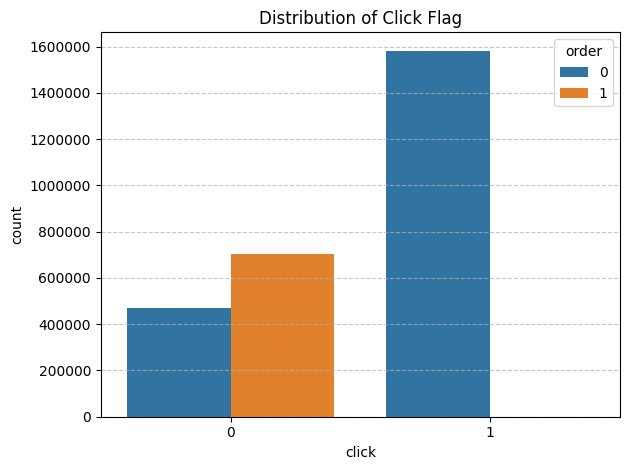

In [14]:
# Distribution of click flag
# =================================================================================

# Numbers
click_counts = df['click'].value_counts()
click_percentages = (df['click'].value_counts(normalize=True) * 100).round(2)
click_order_ct = pd.crosstab(df['click'], df['order'])
click_order_ct_pct = (pd.crosstab(df['click'], df['order'], normalize='index') * 100).round(2)
click_EDA_df = pd.DataFrame({
    'total_count': click_counts,
    'total_percentage': click_percentages,
    'order_0_count': click_order_ct[0],
    'order_1_count': click_order_ct[1],
    'order_0_percentage': click_order_ct_pct[0],
    'order_1_percentage': click_order_ct_pct[1]
})
print(click_EDA_df)
click_EDA_df.to_csv('../data/processed/EDA/click.csv', index=True)

# Visualization
plot = sns.countplot(x="click", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Click Flag")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().xaxis.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/EDA/click.png')
plt.show()

### Categorical Features

#### ***Pid***

- High-Cardinality Categorical Feature
- Long-tail distribution

Number of unique PIDs: 21928

Top 20 PIDs (and Others) by Interaction and Order Count:
order   total_event_count  total_event_percentage  order_count  \
2655                53785                    1.95          525   
2491                14666                    0.53         8473   
16641               12369                    0.45         4866   
16144               11134                    0.40         4739   
7403                10002                    0.36         4767   
3853                 8683                    0.32         3185   
1426                 8396                    0.30         4281   
1247                 7949                    0.29         2990   
1037                 7933                    0.29         4438   
1567                 7761                    0.28         3531   
11569                7526                    0.27         3355   
1145                 6833                    0.25         1314   
4070                 6522                    0.24      

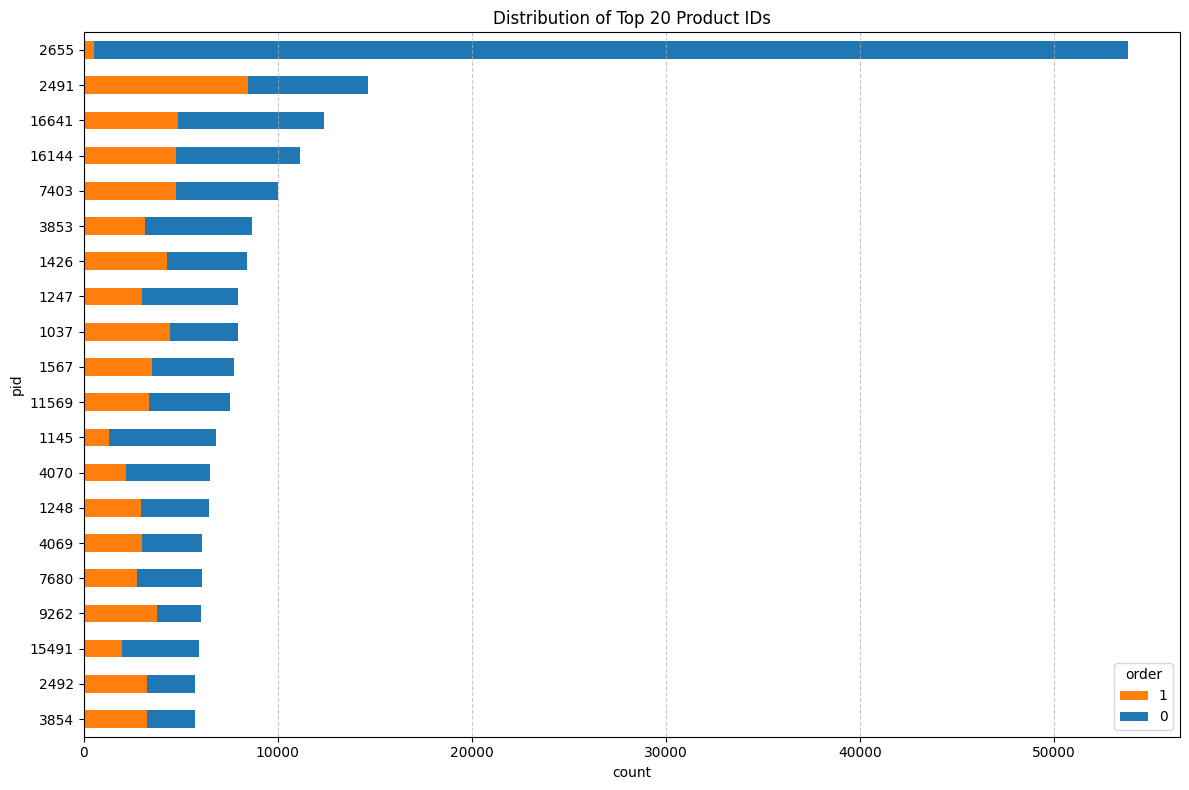

In [15]:
# Distribution of product IDs (PIDs)
# =================================================================================

# Numbers
all_pid_counts_total = df['pid'].value_counts()
top_20_pids_list = all_pid_counts_total.head(20).index
all_pid_order_counts = df.pivot_table(index='pid', columns='order', aggfunc='size', fill_value=0)
all_pid_order_counts['total_events'] = all_pid_order_counts.sum(axis=1)
top_20_counts = all_pid_order_counts.loc[top_20_pids_list]
other_pids = all_pid_order_counts.drop(top_20_pids_list)
other_counts = other_pids.sum().to_frame('others').T
pid_EDA_df = pd.concat([top_20_counts, other_counts])
total_events = df.shape[0]
total_orders = df['order'].sum()
total_no_orders = total_events - total_orders
pid_EDA_df['total_event_percentage'] = (pid_EDA_df['total_events'] / total_events * 100).round(2)
pid_EDA_df['order_count'] = pid_EDA_df[1]
pid_EDA_df['order_percentage'] = (pid_EDA_df[1] / total_orders * 100).round(2)
pid_EDA_df['no_order_count'] = pid_EDA_df[0]
pid_EDA_df['no_order_percentage'] = (pid_EDA_df[0] / total_no_orders * 100).round(2)
pid_EDA_df = pid_EDA_df[['total_events', 'total_event_percentage', 'order_count', 'order_percentage', 'no_order_count', 'no_order_percentage']]
pid_EDA_df.rename(columns={'total_events': 'total_event_count'}, inplace=True)
pid_EDA_df.to_csv('../data/processed/EDA/pid.csv', index=True)
print("Number of unique PIDs:", df['pid'].unique().shape[0])
print("\nTop 20 PIDs (and Others) by Interaction and Order Count:")
print(pid_EDA_df)

# Visualization
top_20_pids_list_viz = df['pid'].value_counts().head(20).index
df_top20_pid = df[df['pid'].isin(top_20_pids_list_viz)]
pid_order_counts_viz = df_top20_pid.pivot_table(index='pid', columns='order', aggfunc='size', fill_value=0)
pid_order_counts_viz = pid_order_counts_viz.reindex(top_20_pids_list_viz)
pid_order_counts_viz = pid_order_counts_viz[[1, 0]]
colors = ['tab:orange', 'tab:blue']
pid_order_counts_viz.plot(kind='barh', stacked=True, figsize=(12, 8), color=colors)
plt.title('Distribution of Top 20 Product IDs')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().yaxis.grid(False)
plt.xlabel('count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/processed/EDA/pid.png')
plt.show()

#### ***Manufacturer***

- High-Cardinality Categorical Feature
- Long-tail distribution

Number of unique Manufacturers: 1065

Top 20 Manufacturers (and Others) by Interaction and Order Count:
order   total_event_count  total_event_percentage  order_count  \
84                 146079                    5.30        51815   
82                 111712                    4.05        37850   
18                 105665                    3.83        31848   
52                 104694                    3.80        36180   
156                 89827                    3.26         9527   
176                 77729                    2.82        26857   
105                 62011                    2.25        21884   
4                   55928                    2.03        20311   
37                  51836                    1.88        16909   
1                   51017                    1.85        13731   
89                  48303                    1.75        14663   
79                  44862                    1.63        10613   
47                  32082             

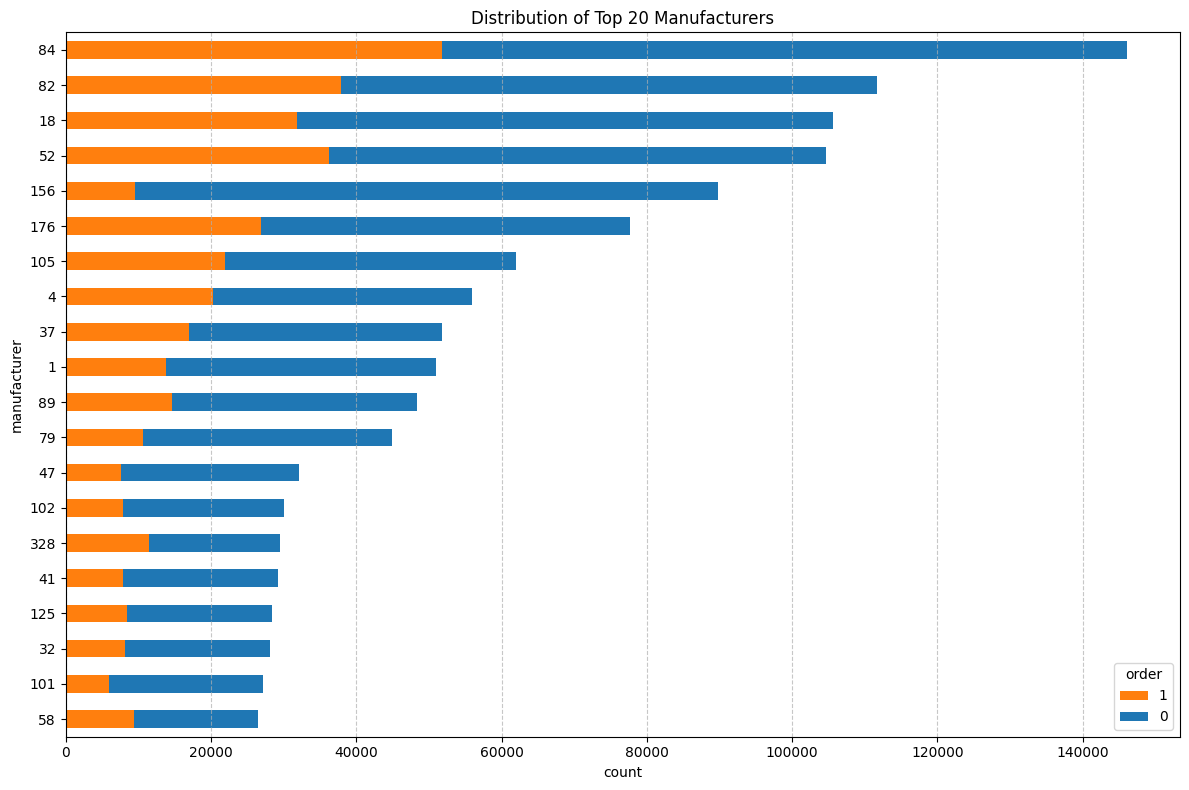

In [16]:
# Distribution of manufacturers
# =================================================================================

# Numbers
all_manufacturer_counts_total = df['manufacturer'].value_counts()
top_20_manufacturer_list = all_manufacturer_counts_total.head(20).index
all_manufacturer_order_counts = df.pivot_table(index='manufacturer', columns='order', aggfunc='size', fill_value=0)
all_manufacturer_order_counts['total_events'] = all_manufacturer_order_counts.sum(axis=1)
top_20_counts = all_manufacturer_order_counts.loc[top_20_manufacturer_list]
other_manufacturers = all_manufacturer_order_counts.drop(top_20_manufacturer_list)
other_counts = other_manufacturers.sum().to_frame('others').T
manufacturer_EDA_df = pd.concat([top_20_counts, other_counts])
total_events = df.shape[0]
total_orders = df['order'].sum()
total_no_orders = total_events - total_orders
manufacturer_EDA_df['total_event_percentage'] = (manufacturer_EDA_df['total_events'] / total_events * 100).round(2)
manufacturer_EDA_df['order_count'] = manufacturer_EDA_df[1]
manufacturer_EDA_df['order_percentage'] = (manufacturer_EDA_df[1] / total_orders * 100).round(2)
manufacturer_EDA_df['no_order_count'] = manufacturer_EDA_df[0]
manufacturer_EDA_df['no_order_percentage'] = (manufacturer_EDA_df[0] / total_no_orders * 100).round(2)
manufacturer_EDA_df = manufacturer_EDA_df[['total_events', 'total_event_percentage', 'order_count', 'order_percentage', 'no_order_count', 'no_order_percentage']]
manufacturer_EDA_df.rename(columns={'total_events': 'total_event_count'}, inplace=True)
manufacturer_EDA_df.to_csv('../data/processed/EDA/manufacturer.csv', index=True)
print("Number of unique Manufacturers:", df['manufacturer'].unique().shape[0])
print("\nTop 20 Manufacturers (and Others) by Interaction and Order Count:")
print(manufacturer_EDA_df)

# Visualization
top_20_manufacturers_list_viz = df['manufacturer'].value_counts().head(20).index
df_top20_manufacturer = df[df['manufacturer'].isin(top_20_manufacturers_list_viz)]
manufacturer_order_counts_viz = df_top20_manufacturer.pivot_table(index='manufacturer', columns='order', aggfunc='size', fill_value=0)
manufacturer_order_counts_viz = manufacturer_order_counts_viz.reindex(top_20_manufacturers_list_viz)
manufacturer_order_counts_viz = manufacturer_order_counts_viz[[1, 0]]
colors = ['tab:orange', 'tab:blue']
manufacturer_order_counts_viz.plot(kind='barh', stacked=True, figsize=(12, 8), color=colors)
plt.title('Distribution of Top 20 Manufacturers')
plt.xlabel('count')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().yaxis.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/EDA/manufacturer.png')
plt.show()

#### ***Content***

- High-Cardinality Categorical Feature
- Long-tail distribution

Number of unique Contents: 548

Top 20 Contents (and Others) by Interaction and Order Count:
order   total_event_count  total_event_percentage  order_count  \
50                 380869                   13.82        93724   
100                338015                   12.26        88553   
20                 312231                   11.33        94228   
10                 219805                    7.98        60632   
1                  167216                    6.07        27907   
30                 134279                    4.87        29102   
200                112206                    4.07        31677   
60                  87661                    3.18        17377   
40                  61460                    2.23        16410   
120                 59715                    2.17        12960   
150                 59096                    2.14        18270   
15                  58036                    2.11        19443   
25                  42682                    1.55

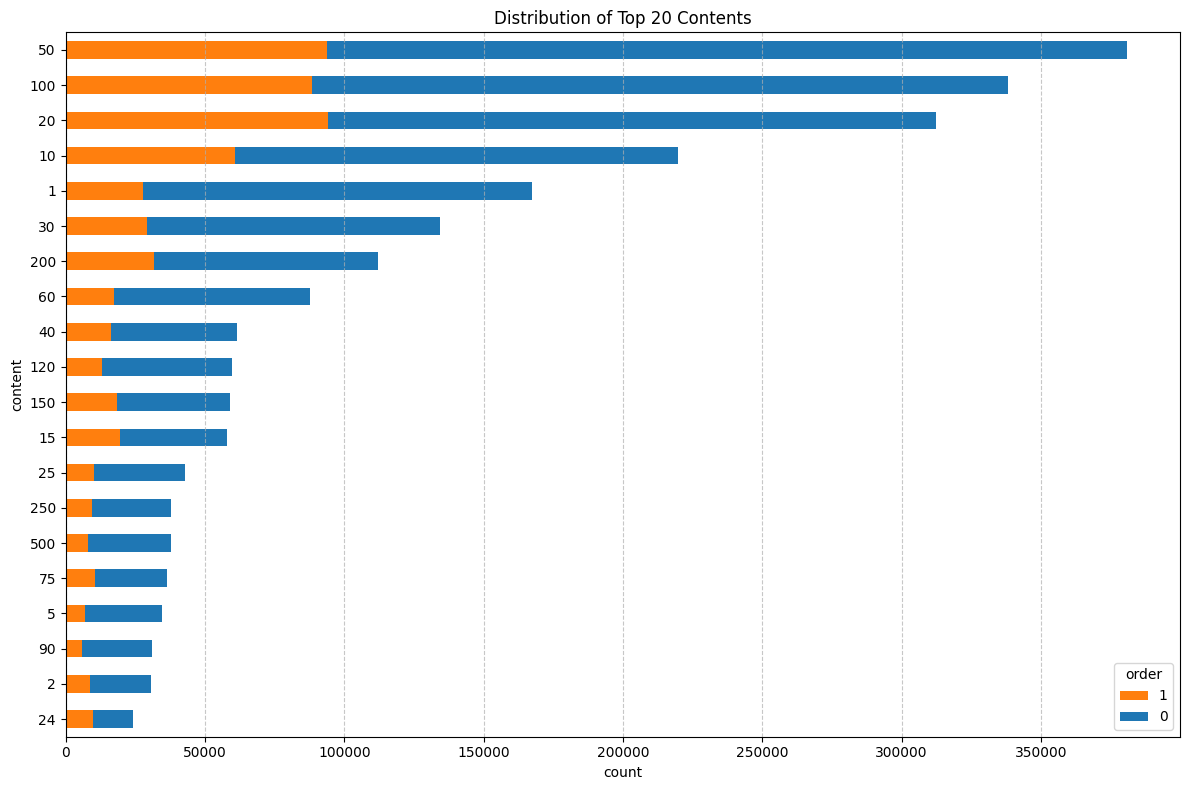

In [17]:
# Distribution of contents
# =================================================================================

# Numbers
all_content_counts_total = df['content'].value_counts()
top_20_content_list = all_content_counts_total.head(20).index
all_content_order_counts = df.pivot_table(index='content', columns='order', aggfunc='size', fill_value=0)
all_content_order_counts['total_events'] = all_content_order_counts.sum(axis=1)
top_20_counts = all_content_order_counts.loc[top_20_content_list]
other_contents = all_content_order_counts.drop(top_20_content_list)
other_counts = other_contents.sum().to_frame('others').T
content_EDA_df = pd.concat([top_20_counts, other_counts])
total_events = df.shape[0]
total_orders = df['order'].sum()
total_no_orders = total_events - total_orders
content_EDA_df['total_event_percentage'] = (content_EDA_df['total_events'] / total_events * 100).round(2)
content_EDA_df['order_count'] = content_EDA_df[1]
content_EDA_df['order_percentage'] = (content_EDA_df[1] / total_orders * 100).round(2)
content_EDA_df['no_order_count'] = content_EDA_df[0]
content_EDA_df['no_order_percentage'] = (content_EDA_df[0] / total_no_orders * 100).round(2)
content_EDA_df = content_EDA_df[['total_events', 'total_event_percentage', 'order_count', 'order_percentage', 'no_order_count', 'no_order_percentage']]
content_EDA_df.rename(columns={'total_events': 'total_event_count'}, inplace=True)
content_EDA_df.to_csv('../data/processed/EDA/content.csv', index=True)
print("Number of unique Contents:", df['content'].unique().shape[0])
print("\nTop 20 Contents (and Others) by Interaction and Order Count:")
print(content_EDA_df)

# Visualization
top_20_contents_list_viz = df['content'].value_counts().head(20).index
df_top20_content = df[df['content'].isin(top_20_contents_list_viz)]
content_order_counts_viz = df_top20_content.pivot_table(index='content', columns='order', aggfunc='size', fill_value=0)
content_order_counts_viz = content_order_counts_viz.reindex(top_20_contents_list_viz)
content_order_counts_viz = content_order_counts_viz[[1, 0]]
colors = ['tab:orange', 'tab:blue']
content_order_counts_viz.plot(kind='barh', stacked=True, figsize=(12, 8), color=colors)
plt.title('Distribution of Top 20 Contents')
plt.xlabel('count')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().yaxis.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/EDA/content.png')
plt.show()

#### ***Group***

- High-Cardinality Categorical Feature
- Long-tail distribution

Number of unique Groups: 533

Top 20 Groups (and Others) by Interaction and Order Count:
order     total_event_count  total_event_percentage  order_count  \
22OI3                159787                    5.80        37760   
2FOI                 148449                    5.39        33843   
21OKG                110419                    4.01        15777   
18OI0EOI              96243                    3.49        36461   
21OK3                 71052                    2.58        14883   
1COS2                 55938                    2.03         1259   
1DOIF0ZO              47419                    1.72        11771   
18OZ00IS              46010                    1.67        15414   
1COI00OT              44421                    1.61        24334   
20OHG                 42005                    1.52         6452   
21OIG                 39180                    1.42         7626   
21OK2                 38194                    1.39        10557   
19OZ1ESI              34933

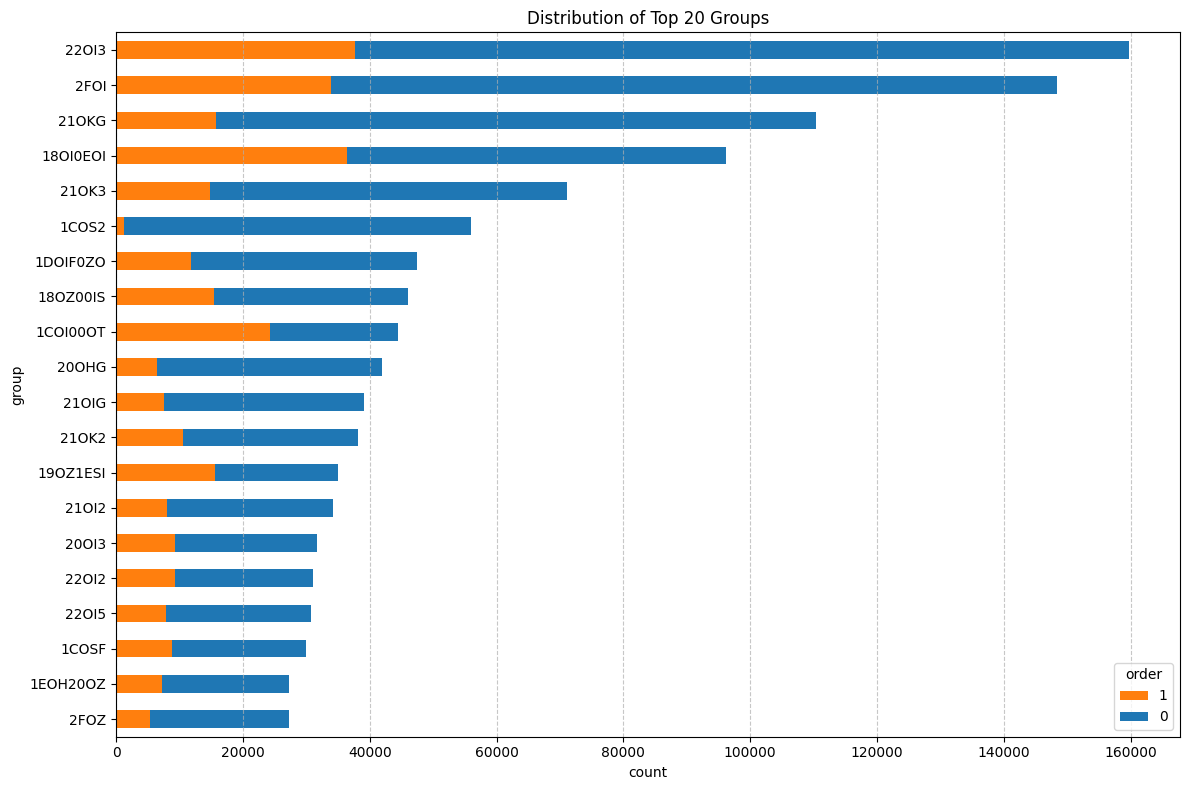

In [18]:
# Distribution of groups
# =================================================================================

# Numbers
all_group_counts_total = df['group'].value_counts()
top_20_group_list = all_group_counts_total.head(20).index
all_group_order_counts = df.pivot_table(index='group', columns='order', aggfunc='size', fill_value=0)
all_group_order_counts['total_events'] = all_group_order_counts.sum(axis=1)
top_20_counts = all_group_order_counts.loc[top_20_group_list]
other_groups = all_group_order_counts.drop(top_20_group_list)
other_counts = other_groups.sum().to_frame('others').T
group_EDA_df = pd.concat([top_20_counts, other_counts])
total_events = df.shape[0]
total_orders = df['order'].sum()
total_no_orders = total_events - total_orders
group_EDA_df['total_event_percentage'] = (group_EDA_df['total_events'] / total_events * 100).round(2)
group_EDA_df['order_count'] = group_EDA_df[1]
group_EDA_df['order_percentage'] = (group_EDA_df[1] / total_orders * 100).round(2)
group_EDA_df['no_order_count'] = group_EDA_df[0]
group_EDA_df['no_order_percentage'] = (group_EDA_df[0] / total_no_orders * 100).round(2)
group_EDA_df = group_EDA_df[['total_events', 'total_event_percentage', 'order_count', 'order_percentage', 'no_order_count', 'no_order_percentage']]
group_EDA_df.rename(columns={'total_events': 'total_event_count'}, inplace=True)
group_EDA_df.to_csv('../data/processed/EDA/group.csv', index=True)
print("Number of unique Groups:", df['group'].unique().shape[0])
print("\nTop 20 Groups (and Others) by Interaction and Order Count:")
print(group_EDA_df)

# Visualization
top_20_groups_list_viz = df['group'].value_counts().head(20).index
df_top20_group = df[df['group'].isin(top_20_groups_list_viz)]
group_order_counts_viz = df_top20_group.pivot_table(index='group', columns='order', aggfunc='size', fill_value=0)
group_order_counts_viz = group_order_counts_viz.reindex(top_20_groups_list_viz)
group_order_counts_viz = group_order_counts_viz[[1, 0]]
colors = ['tab:orange', 'tab:blue']
group_order_counts_viz.plot(kind='barh', stacked=True, figsize=(12, 8), color=colors)
plt.title('Distribution of Top 20 Groups')
plt.xlabel('count')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().yaxis.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/EDA/group.png')
plt.show()

#### ***Pharm Form***

- High-Cardinality Categorical Feature
- Long-tail distribution

Number of unique PharmForms: 279

Top 20 PharmForms (and Others) by Interaction and Order Count:
order   total_event_count  total_event_percentage  order_count  \
TAB                252906                    9.18        75806   
CRE                196138                    7.12        50931   
FTA                182441                    6.62        57067   
GEL                147438                    5.35        43186   
KAP                141001                    5.12        24962   
LOE                129541                    4.70        31572   
FLU                105811                    3.84        14806   
SAL                 97753                    3.55        24887   
SPR                 62256                    2.26        13196   
NAS                 54770                    1.99        26229   
PUL                 54431                    1.97        10053   
ATR                 52477                    1.90        12901   
HKP                 51584                    

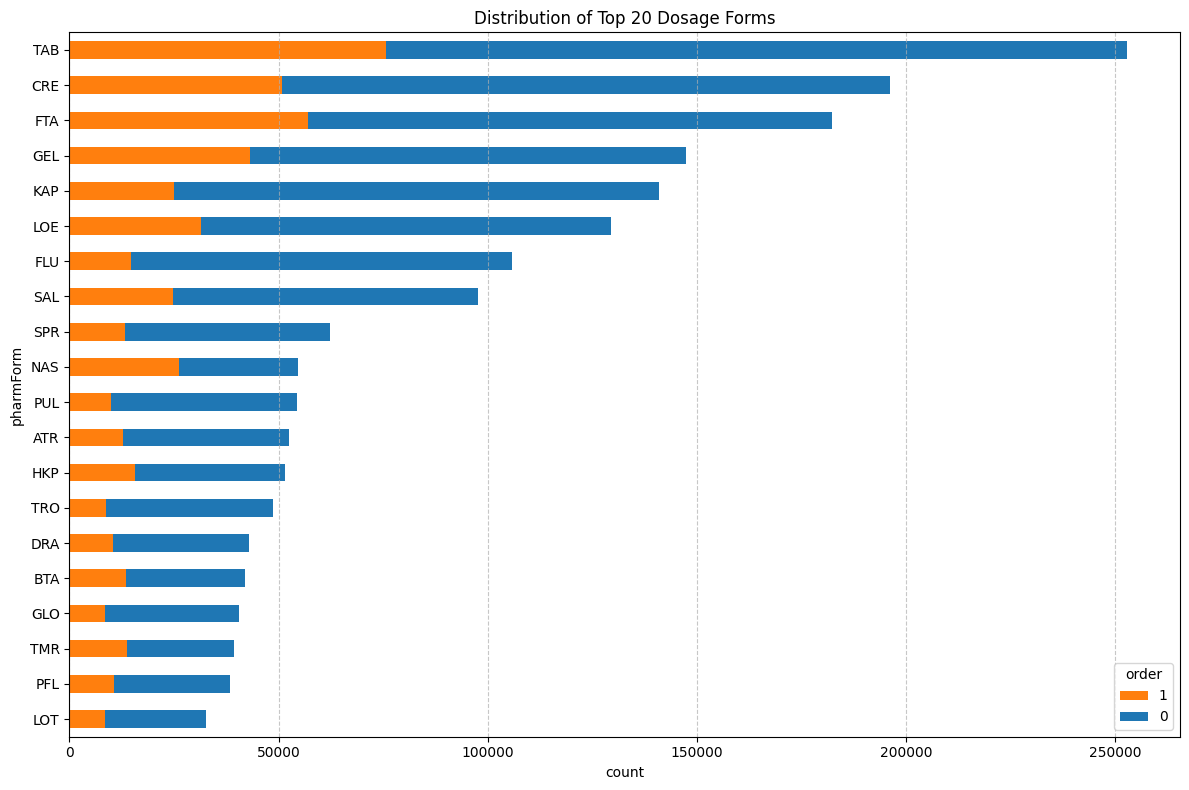

In [19]:
# Distribution of dosage forms (pharmForm)
# =================================================================================

# Numbers
all_pharmForm_counts_total = df['pharmForm'].value_counts()
top_20_pharmForm_list = all_pharmForm_counts_total.head(20).index
all_pharmForm_order_counts = df.pivot_table(index='pharmForm', columns='order', aggfunc='size', fill_value=0)
all_pharmForm_order_counts['total_events'] = all_pharmForm_order_counts.sum(axis=1)
top_20_counts = all_pharmForm_order_counts.loc[top_20_pharmForm_list]
other_pharmForms = all_pharmForm_order_counts.drop(top_20_pharmForm_list)
other_counts = other_pharmForms.sum().to_frame('others').T
pharmForm_EDA_df = pd.concat([top_20_counts, other_counts])
total_events = df.shape[0]
total_orders = df['order'].sum()
total_no_orders = total_events - total_orders
pharmForm_EDA_df['total_event_percentage'] = (pharmForm_EDA_df['total_events'] / total_events * 100).round(2)
pharmForm_EDA_df['order_count'] = pharmForm_EDA_df[1]
pharmForm_EDA_df['order_percentage'] = (pharmForm_EDA_df[1] / total_orders * 100).round(2)
pharmForm_EDA_df['no_order_count'] = pharmForm_EDA_df[0]
pharmForm_EDA_df['no_order_percentage'] = (pharmForm_EDA_df[0] / total_no_orders * 100).round(2)
pharmForm_EDA_df = pharmForm_EDA_df[['total_events', 'total_event_percentage', 'order_count', 'order_percentage', 'no_order_count', 'no_order_percentage']]
pharmForm_EDA_df.rename(columns={'total_events': 'total_event_count'}, inplace=True)
pharmForm_EDA_df.to_csv('../data/processed/EDA/pharmForm.csv', index=True)
print("Number of unique PharmForms:", df['pharmForm'].unique().shape[0])
print("\nTop 20 PharmForms (and Others) by Interaction and Order Count:")
print(pharmForm_EDA_df)

# Visualization
top_20_pharmForms_list_viz = df['pharmForm'].value_counts().head(20).index
df_top20_pharmForm = df[df['pharmForm'].isin(top_20_pharmForms_list_viz)]
pharmForm_order_counts_viz = df_top20_pharmForm.pivot_table(index='pharmForm', columns='order', aggfunc='size', fill_value=0)
pharmForm_order_counts_viz = pharmForm_order_counts_viz.reindex(top_20_pharmForms_list_viz)
pharmForm_order_counts_viz = pharmForm_order_counts_viz[[1, 0]]
colors = ['tab:orange', 'tab:blue']
pharmForm_order_counts_viz.plot(kind='barh', stacked=True, figsize=(12, 8), color=colors)
plt.title('Distribution of Top 20 Dosage Forms')
plt.xlabel('count')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().yaxis.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/EDA/pharmForm.png')
plt.show()

#### ***Category***

- High-Cardinality Categorical Feature
- Long-tail distribution

Number of unique Categories: 410

Top 20 Categories (and Others) by Interaction and Order Count:
order   total_event_count  total_event_percentage  order_count  \
50.0               118323                    4.29        46943   
66.0                65987                    2.39        28266   
90.0                64779                    2.35        18970   
101.0               63884                    2.32        16413   
116.0               62340                    2.26         3360   
25.0                61986                    2.25        18057   
132.0               50639                    1.84        23694   
9.0                 47142                    1.71        12959   
12.0                42829                    1.55        11568   
39.0                42281                    1.53        10748   
71.0                40925                    1.48        13675   
46.0                40681                    1.48        11542   
121.0               40008                    

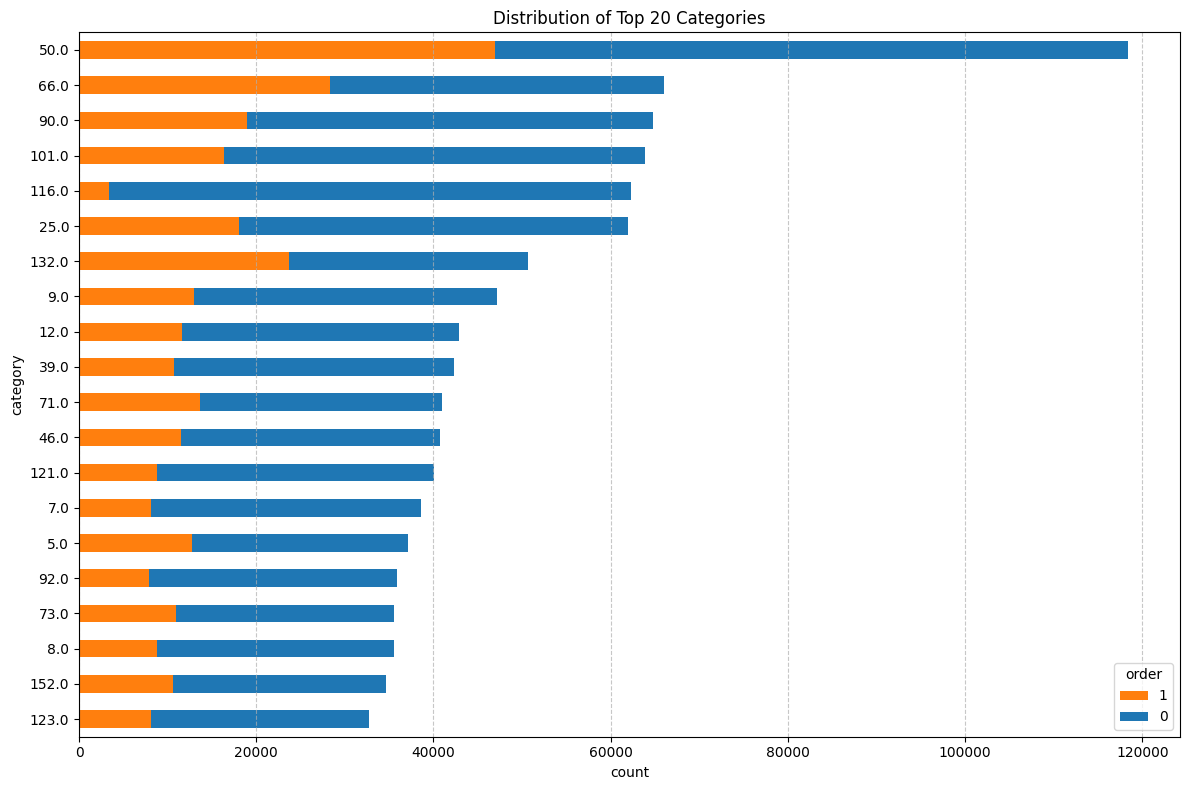

In [20]:
# Distribution of categories
# =================================================================================

# Numbers
all_category_counts_total = df['category'].value_counts()
top_20_category_list = all_category_counts_total.head(20).index
all_category_order_counts = df.pivot_table(index='category', columns='order', aggfunc='size', fill_value=0)
all_category_order_counts['total_events'] = all_category_order_counts.sum(axis=1)
top_20_counts = all_category_order_counts.loc[top_20_category_list]
other_categories = all_category_order_counts.drop(top_20_category_list)
other_counts = other_categories.sum().to_frame('others').T
category_EDA_df = pd.concat([top_20_counts, other_counts])
total_events = df.shape[0]
total_orders = df['order'].sum()
total_no_orders = total_events - total_orders
category_EDA_df['total_event_percentage'] = (category_EDA_df['total_events'] / total_events * 100).round(2)
category_EDA_df['order_count'] = category_EDA_df[1]
category_EDA_df['order_percentage'] = (category_EDA_df[1] / total_orders * 100).round(2)
category_EDA_df['no_order_count'] = category_EDA_df[0]
category_EDA_df['no_order_percentage'] = (category_EDA_df[0] / total_no_orders * 100).round(2)
category_EDA_df = category_EDA_df[['total_events', 'total_event_percentage', 'order_count', 'order_percentage', 'no_order_count', 'no_order_percentage']]
category_EDA_df.rename(columns={'total_events': 'total_event_count'}, inplace=True)
category_EDA_df.to_csv('../data/processed/EDA/category.csv', index=True)
print("Number of unique Categories:", df['category'].unique().shape[0])
print("\nTop 20 Categories (and Others) by Interaction and Order Count:")
print(category_EDA_df)

# Visualization
top_20_categories_list_viz = df['category'].value_counts().head(20).index
df_top20_category = df[df['category'].isin(top_20_categories_list_viz)]
category_order_counts_viz = df_top20_category.pivot_table(index='category', columns='order', aggfunc='size', fill_value=0)
category_order_counts_viz = category_order_counts_viz.reindex(top_20_categories_list_viz)
category_order_counts_viz = category_order_counts_viz[[1, 0]]
colors = ['tab:orange', 'tab:blue']
category_order_counts_viz.plot(kind='barh', stacked=True, figsize=(12, 8), color=colors)
plt.title('Distribution of Top 20 Categories')
plt.xlabel('count')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().yaxis.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/EDA/category.png')
plt.show()

#### ***Day***

     total_count  total_percentage  order_0_count  order_1_count  \
day                                                                
1          18358              0.67          11888           6470   
2          17331              0.63          11308           6023   
3          24669              0.90          14854           9815   
4          24833              0.90          15075           9758   
5          26520              0.96          16845           9675   
6          25223              0.92          15818           9405   
7          19779              0.72          12537           7242   
8          16868              0.61          10951           5917   
9          14860              0.54           9959           4901   
10         24054              0.87          14822           9232   
11         26465              0.96          16770           9695   
12         27300              0.99          17170          10130   
13         24415              0.89          1556

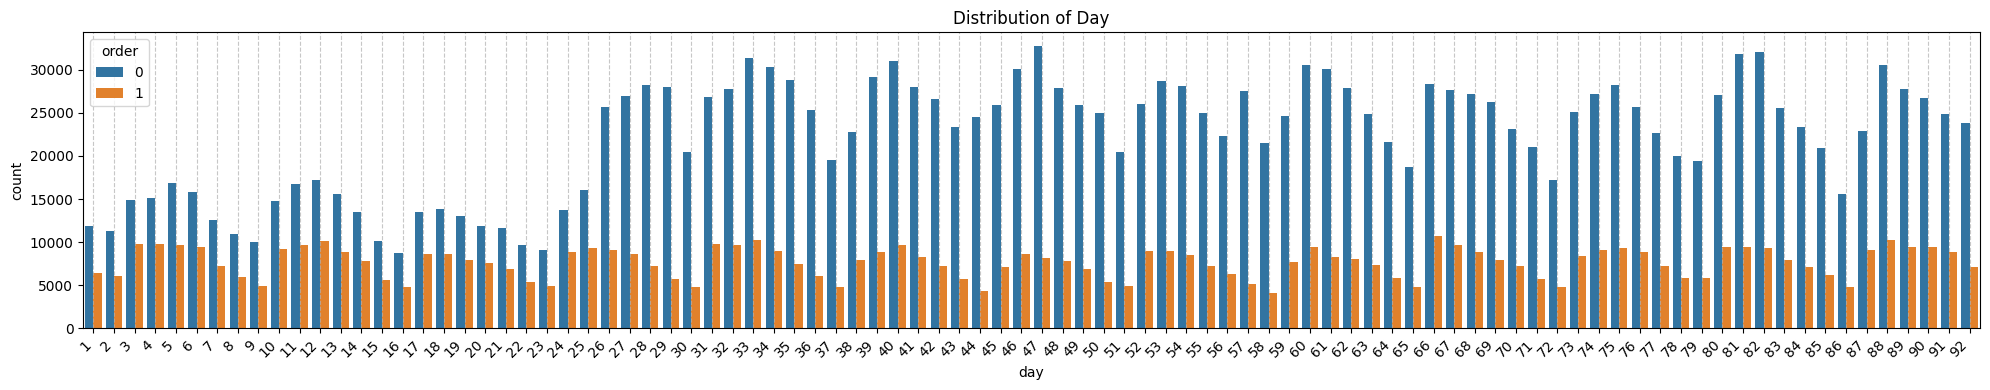

In [21]:
# Distribution of days
# =================================================================================

# Numbers
day_counts = df['day'].value_counts()
day_percentages = (df['day'].value_counts(normalize=True) * 100).round(2)
day_order_ct = pd.crosstab(df['day'], df['order'])
day_order_ct_pct = (pd.crosstab(df['day'], df['order'], normalize='index') * 100).round(2)
day_EDA_df = pd.DataFrame({
    'total_count': day_counts,
    'total_percentage': day_percentages,
    'order_0_count': day_order_ct[0],
    'order_1_count': day_order_ct[1],
    'order_0_percentage': day_order_ct_pct[0],
    'order_1_percentage': day_order_ct_pct[1]
})
print(day_EDA_df)
day_EDA_df.to_csv('../data/processed/EDA/day.csv', index=True)

# Visualization
plt.figure(figsize=(20, 4))
plot = sns.countplot(data=df, x="day", hue="order")
plot.set_title("Distribution of Day")
plot.tick_params(axis="x", labelrotation=45)
for label in plot.get_xticklabels():
    label.set_ha("right")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().yaxis.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/EDA/day.png')
plt.show()

Saved figure to: /Users/annageiser/Documents/GITHUB/analytics-project/data/processed/eda/day_analysis_overview.png


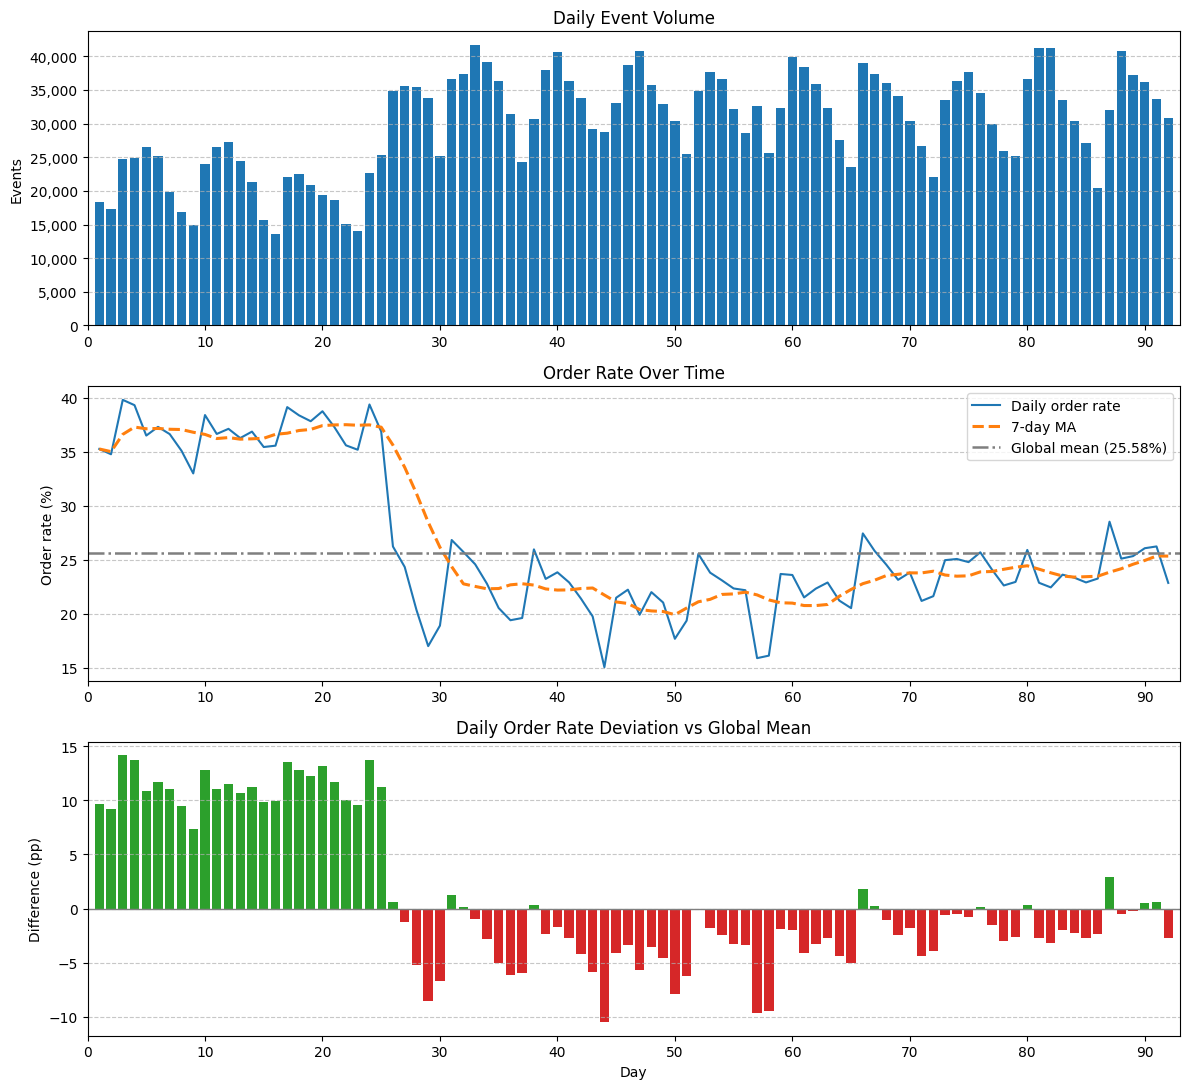

Saved figure to: /Users/annageiser/Documents/GITHUB/analytics-project/data/processed/eda/day_analysis_7day_cycle_pattern.png


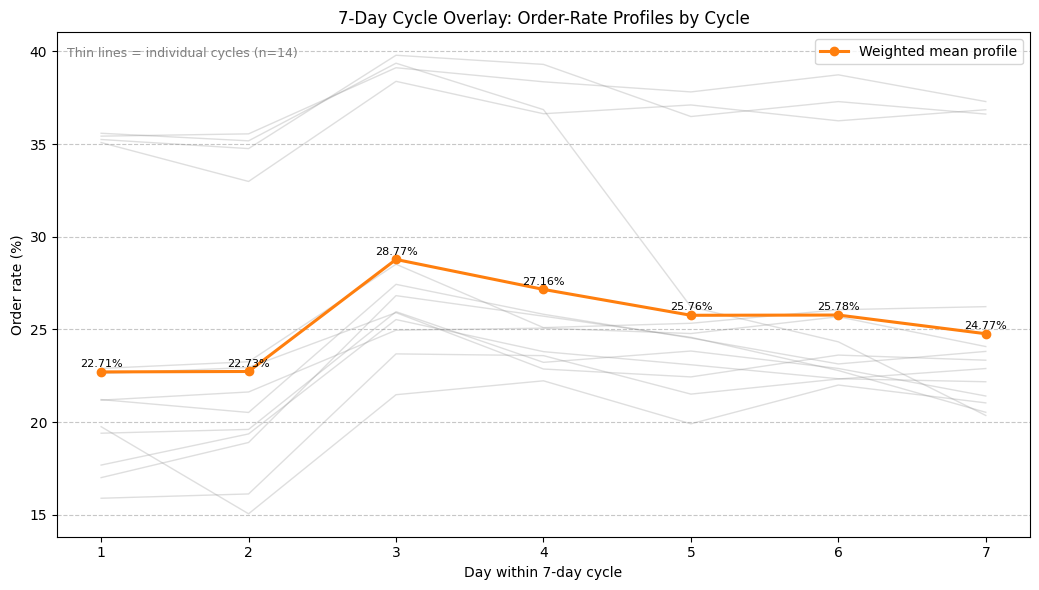

=== Day Analysis Data Integrity Checks ===
day_min: 1
day_max: 92
unique_days: 92
is_consecutive: True
missing_days: []

=== Day Analysis Summary ===
Days covered: 1 to 92 (92 days)
Total events: 2,756,003
Total orders: 705,090
Global order rate: 25.58%
Peak day: 3 | order rate=39.79% | events=24,669
Lowest day: 44 | order rate=15.06% | events=28,810

=== 7-Day Cycle Insight ===
Best cycle day: 3 | weighted order rate=28.77% | avg events/day=30944
Lowest cycle day: 1 | weighted order rate=22.71% | avg events/day=25818

=== Phase Summary ===
         regime  start_day  end_day  n_days  total_events  orders  weighted_order_rate
      pre_break          1       31      31        723274  238858             0.330246
transition_week         32       38       7        240927   55062             0.228542
     post_break         39       92      54       1791802  411170             0.229473


In [22]:
# Further exploration of day variable (time series analysis, structural change detection, etc.)

# 1) Validation and setup
required_cols = {"day", "order"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns in df: {sorted(missing_cols)}")

PROCESSED_DIR = Path("../data/processed/eda")
FIGURES_DIR = Path("../data/processed/eda")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df_analysis = df.loc[:, ["day", "order"]].copy()

# Coerce day to numeric safely
df_analysis["day"] = pd.to_numeric(df_analysis["day"], errors="coerce")
if df_analysis["day"].isna().any():
    bad_rows = int(df_analysis["day"].isna().sum())
    raise ValueError(f"Column day contains {bad_rows} non-numeric values.")

# Optional strictness: day should be integer-like and positive
if not np.allclose(df_analysis["day"], np.floor(df_analysis["day"])):
    raise ValueError("Column day must be integer-like values.")
if (df_analysis["day"] <= 0).any():
    raise ValueError("Column day must be positive.")

df_analysis["day"] = df_analysis["day"].astype(int)

# Validate order is binary
order_values = set(df_analysis["order"].dropna().unique())
if not order_values.issubset({0, 1}):
    raise ValueError(f"Column order must be binary (0/1). Found: {sorted(order_values)}")

# 2) Daily aggregation
daily_stats = (
    df_analysis.groupby("day", as_index=False)
    .agg(
        total_events=("order", "size"),
        orders=("order", "sum"),
    )
    .sort_values("day")
)

daily_stats["order_rate"] = daily_stats["orders"] / daily_stats["total_events"]
daily_stats["non_orders"] = daily_stats["total_events"] - daily_stats["orders"]

# Rolling signals
daily_stats["order_rate_7d_ma"] = daily_stats["order_rate"].rolling(window=7, min_periods=1).mean()
daily_stats["order_rate_14d_ma"] = daily_stats["order_rate"].rolling(window=14, min_periods=1).mean()

# Global baseline
global_order_rate = df_analysis["order"].mean()
daily_stats["order_rate_vs_global_pp"] = (daily_stats["order_rate"] - global_order_rate) * 100

# 3) Structural change detection (simple and interpretable)
# Largest absolute 7-day MA shift over a 7-day lag
daily_stats["ma7_change_abs"] = (daily_stats["order_rate_7d_ma"] - daily_stats["order_rate_7d_ma"].shift(7)).abs()

if daily_stats["ma7_change_abs"].notna().any():
    break_idx = daily_stats["ma7_change_abs"].idxmax()
    break_day = int(daily_stats.loc[break_idx, "day"])
else:
    break_day = int(daily_stats["day"].min())

# Regime labeling: pre / transition week / post
daily_stats["regime"] = np.select(
    [
        daily_stats["day"] < break_day,
        daily_stats["day"].between(break_day, break_day + 6, inclusive="both"),
        daily_stats["day"] > break_day + 6,
    ],
    [
        "pre_break",
        "transition_week",
        "post_break",
    ],
    default="post_break",
)

regime_summary = (
    daily_stats.groupby("regime", as_index=False)
    .agg(
        start_day=("day", "min"),
        end_day=("day", "max"),
        n_days=("day", "count"),
        total_events=("total_events", "sum"),
        orders=("orders", "sum"),
    )
    .sort_values("start_day")
)
regime_summary["weighted_order_rate"] = regime_summary["orders"] / regime_summary["total_events"]

# 4) Top/bottom day table
top_days = daily_stats.nlargest(5, "order_rate").copy()
top_days["extreme_type"] = "top_5_rate"

bottom_days = daily_stats.nsmallest(5, "order_rate").copy()
bottom_days["extreme_type"] = "bottom_5_rate"

extreme_days = pd.concat([top_days, bottom_days], ignore_index=True).sort_values(
    ["extreme_type", "order_rate"], ascending=[True, False]
)

# 5) Persist output tables
daily_stats.to_csv(PROCESSED_DIR / "day_analysis_daily_stats.csv", index=False)
regime_summary.to_csv(PROCESSED_DIR / "day_analysis_regime_summary.csv", index=False)
extreme_days.to_csv(PROCESSED_DIR / "day_analysis_extreme_days.csv", index=False)

# 6) Plot overview (3 panels)
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

# Panel A: Daily volume
axes[0].bar(daily_stats["day"], daily_stats["total_events"], color='tab:blue', edgecolor="none")
axes[0].set_title("Daily Event Volume")
axes[0].set_ylabel("Events")
axes[0].grid(axis="y", linestyle='--', alpha=0.7)
axes[0].xaxis.grid(False)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))

# Panel B: Daily order rate with MA + global mean
global_mean_pct = global_order_rate * 100

axes[1].plot(
    daily_stats["day"],
    daily_stats["order_rate"] * 100,
    color='tab:blue',
    linewidth=1.5,
    label="Daily order rate",
)
axes[1].plot(
    daily_stats["day"],
    daily_stats["order_rate_7d_ma"] * 100,
    color='tab:orange',
    linewidth=2.2,
    linestyle="--",
    label="7-day MA",
)

# Global mean reference line
axes[1].axhline(
    global_mean_pct,
    color='tab:gray',
    linestyle="-.",
    linewidth=1.8,
    label=f"Global mean ({global_mean_pct:.2f}%)",
)

axes[1].set_title("Order Rate Over Time")
axes[1].set_ylabel("Order rate (%)")
axes[1].grid(axis="y", linestyle='--', alpha=0.7)
axes[1].xaxis.grid(False)
axes[1].legend(loc="best")

# Panel C: Deviation from global baseline
colors_c = np.where(daily_stats["order_rate_vs_global_pp"] >= 0, 'tab:green', 'tab:red')
axes[2].bar(daily_stats["day"], daily_stats["order_rate_vs_global_pp"], color=colors_c, edgecolor="none")
axes[2].axhline(0, color='tab:gray', linewidth=1)
axes[2].set_title("Daily Order Rate Deviation vs Global Mean")
axes[2].set_xlabel("Day")
axes[2].set_ylabel("Difference (pp)")
axes[2].grid(axis="y", linestyle='--', alpha=0.7)
axes[2].xaxis.grid(False)

x_max = int(daily_stats["day"].max())

# 0, 10, 20, ... 90 (leave out 92)
xticks = list(range(0, x_max, 10))

for ax in axes:
    ax.set_xlim(0, 93)
    ax.set_xticks(xticks)
    ax.tick_params(axis="x", labelbottom=True)

fig.tight_layout()
fig_path = FIGURES_DIR / "day_analysis_overview.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {fig_path.resolve()}")
plt.show()
plt.close(fig)

# 7) 7-day cycle pattern (all cycles overlapped)
cycle_overlay = daily_stats.loc[:, ["day", "total_events", "orders", "order_rate"]].copy()
cycle_overlay["cycle_id"] = ((cycle_overlay["day"] - 1) // 7) + 1
cycle_overlay["day_in_cycle"] = ((cycle_overlay["day"] - 1) % 7) + 1

weekly_pattern = (
    cycle_overlay.groupby("day_in_cycle", as_index=False)
    .agg(
        n_days=("day", "count"),
        total_events=("total_events", "sum"),
        total_orders=("orders", "sum"),
        avg_daily_events=("total_events", "mean"),
        avg_daily_order_rate=("order_rate", "mean"),
        n_cycles_with_data=("cycle_id", "nunique"),
    )
    .sort_values("day_in_cycle")
)
weekly_pattern["weighted_order_rate"] = weekly_pattern["total_orders"] / weekly_pattern["total_events"]
weekly_pattern.to_csv(PROCESSED_DIR / "day_analysis_7day_cycle_summary.csv", index=False)

fig2, ax2 = plt.subplots(figsize=(10.5, 6))

# Thin lines: each 7-day block as its own profile
for _, cycle_df in cycle_overlay.groupby("cycle_id"):
    cycle_df = cycle_df.sort_values("day_in_cycle")
    ax2.plot(
        cycle_df["day_in_cycle"],
        cycle_df["order_rate"] * 100,
        color='tab:gray',
        linewidth=1.0,
        alpha=0.25,
    )

# Bold line: weighted mean profile across all cycles
x = weekly_pattern["day_in_cycle"].to_numpy()
rate_pct = weekly_pattern["weighted_order_rate"].to_numpy() * 100
ax2.plot(
    x,
    rate_pct,
    color='tab:orange',
    marker="o",
    linewidth=2.2,
    label="Weighted mean profile",
)

for x_val, pct in zip(x, rate_pct):
    ax2.text(x_val, pct + 0.15, f"{pct:.2f}%", ha="center", va="bottom", fontsize=8)

ax2.set_title("7-Day Cycle Overlay: Order-Rate Profiles by Cycle")
ax2.set_xlabel("Day within 7-day cycle")
ax2.set_ylabel("Order rate (%)")
ax2.set_xticks(range(1, 8))
ax2.grid(axis="y", linestyle='--', alpha=0.7)
ax2.xaxis.grid(False)
ax2.legend(loc="upper right")
ax2.text(
    0.01,
    0.97,
    f"Thin lines = individual cycles (n={int(cycle_overlay['cycle_id'].nunique())})",
    transform=ax2.transAxes,
    va="top",
    fontsize=9,
    color='tab:gray',
)

fig2.tight_layout()
fig2_path = FIGURES_DIR / "day_analysis_7day_cycle_pattern.png"
fig2.savefig(fig2_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {fig2_path.resolve()}")
plt.show()
plt.close(fig2)

best_cycle = weekly_pattern.loc[weekly_pattern["weighted_order_rate"].idxmax()]
worst_cycle = weekly_pattern.loc[weekly_pattern["weighted_order_rate"].idxmin()]

# 8) Console summary for direct report writing
peak_row = daily_stats.loc[daily_stats["order_rate"].idxmax()]
trough_row = daily_stats.loc[daily_stats["order_rate"].idxmin()]

day_min = int(df["day"].min())
day_max = int(df["day"].max())
n_unique_days = int(df["day"].nunique())

expected_days = set(range(day_min, day_max + 1))
observed_days = set(df["day"].unique())
missing_days = sorted(expected_days - observed_days)

print("=== Day Analysis Data Integrity Checks ===")
print("day_min:", day_min)
print("day_max:", day_max)
print("unique_days:", n_unique_days)
print("is_consecutive:", len(missing_days) == 0)
print("missing_days:", missing_days[:10])

print("\n=== Day Analysis Summary ===")
print(f"Days covered: {daily_stats['day'].min()} to {daily_stats['day'].max()} ({len(daily_stats)} days)")
print(f"Total events: {int(daily_stats['total_events'].sum()):,}")
print(f"Total orders: {int(daily_stats['orders'].sum()):,}")
print(f"Global order rate: {global_order_rate * 100:.2f}%")
print(f"Peak day: {int(peak_row['day'])} | order rate={peak_row['order_rate'] * 100:.2f}% | events={int(peak_row['total_events']):,}")
print(f"Lowest day: {int(trough_row['day'])} | order rate={trough_row['order_rate'] * 100:.2f}% | events={int(trough_row['total_events']):,}")
print("\n=== 7-Day Cycle Insight ===")
print(
    f"Best cycle day: {int(best_cycle['day_in_cycle'])} | weighted order rate={best_cycle['weighted_order_rate'] * 100:.2f}% | avg events/day={best_cycle['avg_daily_events']:.0f}"
)
print(
    f"Lowest cycle day: {int(worst_cycle['day_in_cycle'])} | weighted order rate={worst_cycle['weighted_order_rate'] * 100:.2f}% | avg events/day={worst_cycle['avg_daily_events']:.0f}"
)
print("\n=== Phase Summary ===")
print(regime_summary.to_string(index=False))

#### ***Ad Flag***

        total_count  total_percentage  order_0_count  order_1_count  \
adFlag                                                                
0           1880176             68.22        1457449         422727   
1            875827             31.78         593464         282363   

        order_0_percentage  order_1_percentage  
adFlag                                          
0                    77.52               22.48  
1                    67.76               32.24  


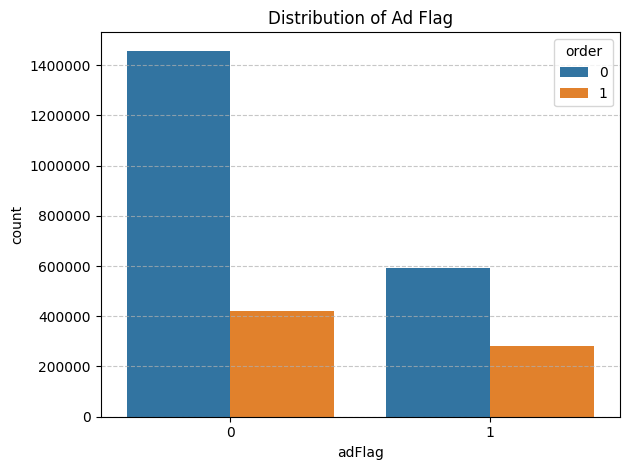

In [23]:
# Distribution of ad flag
# =================================================================================

# Numbers
adFlag_counts = df['adFlag'].value_counts()
adFlag_percentages = (df['adFlag'].value_counts(normalize=True) * 100).round(2)
adFlag_order_ct = pd.crosstab(df['adFlag'], df['order'])
adFlag_order_ct_pct = (pd.crosstab(df['adFlag'], df['order'], normalize='index') * 100).round(2)
adFlag_EDA_df = pd.DataFrame({
    'total_count': adFlag_counts,
    'total_percentage': adFlag_percentages,
    'order_0_count': adFlag_order_ct[0],
    'order_1_count': adFlag_order_ct[1],
    'order_0_percentage': adFlag_order_ct_pct[0],
    'order_1_percentage': adFlag_order_ct_pct[1]
})
print(adFlag_EDA_df)
adFlag_EDA_df.to_csv('../data/processed/EDA/adFlag.csv', index=True)

# Visualization
plot = sns.countplot(x="adFlag", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Ad Flag")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().xaxis.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/EDA/adFlag.png')
plt.show()

#### ***Availability***

              total_count  total_percentage  order_0_count  order_1_count  \
availability                                                                
1                 2515572             91.28        1842116         673456   
2                  185194              6.72         158214          26980   
3                   44893              1.63          40242           4651   
4                   10344              0.38          10341              3   

              order_0_percentage  order_1_percentage  
availability                                          
1                          73.23               26.77  
2                          85.43               14.57  
3                          89.64               10.36  
4                          99.97                0.03  


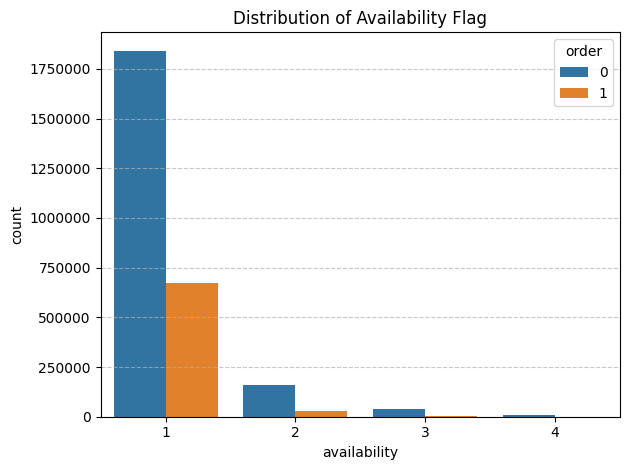

In [24]:
# Distribution of availability
# =================================================================================

# Numbers
availability_counts = df['availability'].value_counts()
availability_percentages = (df['availability'].value_counts(normalize=True) * 100).round(2)
availability_order_ct = pd.crosstab(df['availability'], df['order'])
availability_order_ct_pct = (pd.crosstab(df['availability'], df['order'], normalize='index') * 100).round(2)
availability_EDA_df = pd.DataFrame({
    'total_count': availability_counts,
    'total_percentage': availability_percentages,
    'order_0_count': availability_order_ct[0],
    'order_1_count': availability_order_ct[1],
    'order_0_percentage': availability_order_ct_pct[0],
    'order_1_percentage': availability_order_ct_pct[1]
})
print(availability_EDA_df)
availability_EDA_df.to_csv('../data/processed/EDA/availability.csv', index=True)

# Visualization
plot = sns.countplot(x="availability", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Availability Flag")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().xaxis.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/EDA/availability.png')
plt.show()

#### ***Unit***

      total_count  total_percentage  order_0_count  order_1_count  \
unit                                                                
CM            272              0.01            247             25   
G          472390             17.14         346456         125934   
KG            178              0.01            134             44   
L            2613              0.09           1984            629   
M             591              0.02            396            195   
ML         927879             33.67         702217         225662   
P           19824              0.72          16929           2895   
ST        1332256             48.34         982550         349706   

      order_0_percentage  order_1_percentage  
unit                                          
CM                 90.81                9.19  
G                  73.34               26.66  
KG                 75.28               24.72  
L                  75.93               24.07  
M                  67.01   

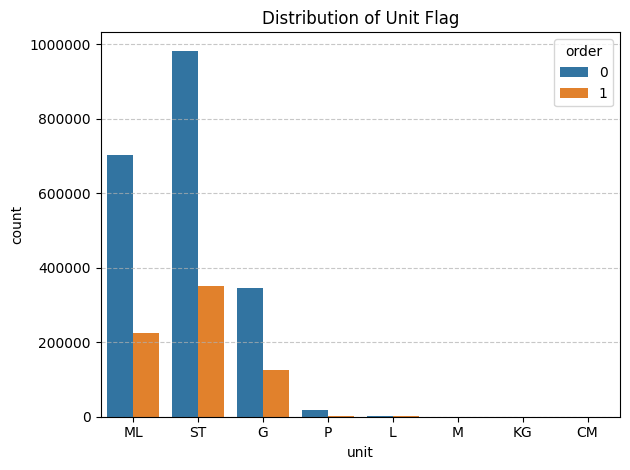

In [25]:
# Distribution of unit flag
# =================================================================================

# Numbers
unit_counts = df['unit'].value_counts()
unit_percentages = (df['unit'].value_counts(normalize=True) * 100).round(2)
unit_order_ct = pd.crosstab(df['unit'], df['order'])
unit_order_ct_pct = (pd.crosstab(df['unit'], df['order'], normalize='index') * 100).round(2)
unit_EDA_df = pd.DataFrame({
    'total_count': unit_counts,
    'total_percentage': unit_percentages,
    'order_0_count': unit_order_ct[0],
    'order_1_count': unit_order_ct[1],
    'order_0_percentage': unit_order_ct_pct[0],
    'order_1_percentage': unit_order_ct_pct[1]
})
print(unit_EDA_df)
unit_EDA_df.to_csv('../data/processed/EDA/unit.csv', index=True)

# Visualization
plot = sns.countplot(x="unit", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Unit Flag")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().xaxis.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/EDA/unit.png')
plt.show()

#### ***Generic Product***

                total_count  total_percentage  order_0_count  order_1_count  \
genericProduct                                                                
0                   2465221             89.45        1869403         595818   
1                    290782             10.55         181510         109272   

                order_0_percentage  order_1_percentage  
genericProduct                                          
0                            75.83               24.17  
1                            62.42               37.58  


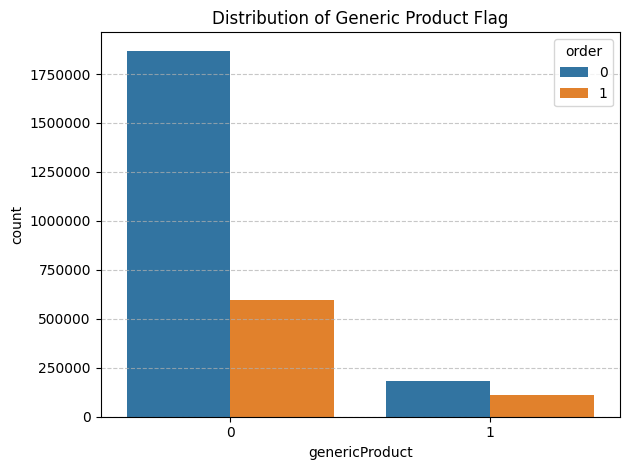

In [26]:
# Distribution of generic product flag
# =================================================================================

# Numbers
genericProduct_counts = df['genericProduct'].value_counts()
genericProduct_percentages = (df['genericProduct'].value_counts(normalize=True) * 100).round(2)
genericProduct_order_ct = pd.crosstab(df['genericProduct'], df['order'])
genericProduct_order_ct_pct = (pd.crosstab(df['genericProduct'], df['order'], normalize='index') * 100).round(2)
genericProduct_EDA_df = pd.DataFrame({
    'total_count': genericProduct_counts,
    'total_percentage': genericProduct_percentages,
    'order_0_count': genericProduct_order_ct[0],
    'order_1_count': genericProduct_order_ct[1],
    'order_0_percentage': genericProduct_order_ct_pct[0],
    'order_1_percentage': genericProduct_order_ct_pct[1]
})
print(genericProduct_EDA_df)
genericProduct_EDA_df.to_csv('../data/processed/EDA/genericProduct.csv', index=True)

# Visualization
plot = sns.countplot(x="genericProduct", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Generic Product Flag")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().xaxis.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/EDA/genericProduct.png')
plt.show()

#### ***Sales Index***

            total_count  total_percentage  order_0_count  order_1_count  \
salesIndex                                                                
40              1398720             50.75         994237         404483   
44                36402              1.32          29504           6898   
52               106734              3.87          81086          25648   
53              1214147             44.05         946086         268061   

            order_0_percentage  order_1_percentage  
salesIndex                                          
40                       71.08               28.92  
44                       81.05               18.95  
52                       75.97               24.03  
53                       77.92               22.08  


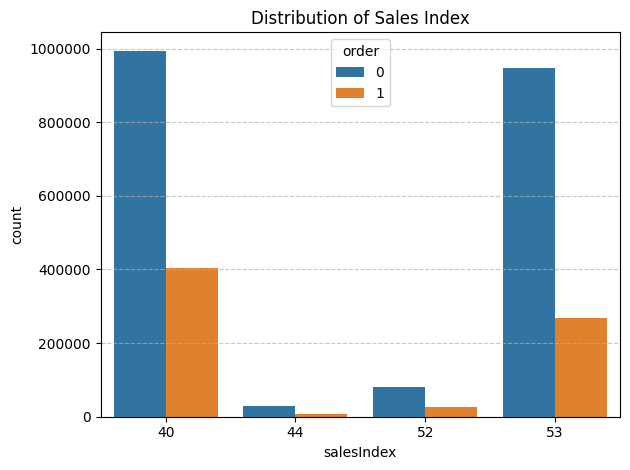

In [27]:
# Distribution of sales index
# =================================================================================

# Numbers
salesIndex_counts = df['salesIndex'].value_counts()
salesIndex_percentages = (df['salesIndex'].value_counts(normalize=True) * 100).round(2)
salesIndex_order_ct = pd.crosstab(df['salesIndex'], df['order'])
salesIndex_order_ct_pct = (pd.crosstab(df['salesIndex'], df['order'], normalize='index') * 100).round(2)
salesIndex_EDA_df = pd.DataFrame({
    'total_count': salesIndex_counts,
    'total_percentage': salesIndex_percentages,
    'order_0_count': salesIndex_order_ct[0],
    'order_1_count': salesIndex_order_ct[1],
    'order_0_percentage': salesIndex_order_ct_pct[0],
    'order_1_percentage': salesIndex_order_ct_pct[1]
})
print(salesIndex_EDA_df)
salesIndex_EDA_df.to_csv('../data/processed/EDA/salesIndex.csv', index=True)

# Visualization
plot = sns.countplot(x="salesIndex", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Sales Index")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().xaxis.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/EDA/salesIndex.png')
plt.show()

#### ***Campaign Index***

               total_count  total_percentage  order_0_count  order_1_count  \
campaignIndex                                                                
A                   144010             30.77          98601          45409   
B                   251965             53.83         187829          64136   
C                    72060             15.40          53138          18922   

               order_0_percentage  order_1_percentage  
campaignIndex                                          
A                           68.47               31.53  
B                           74.55               25.45  
C                           73.74               26.26  


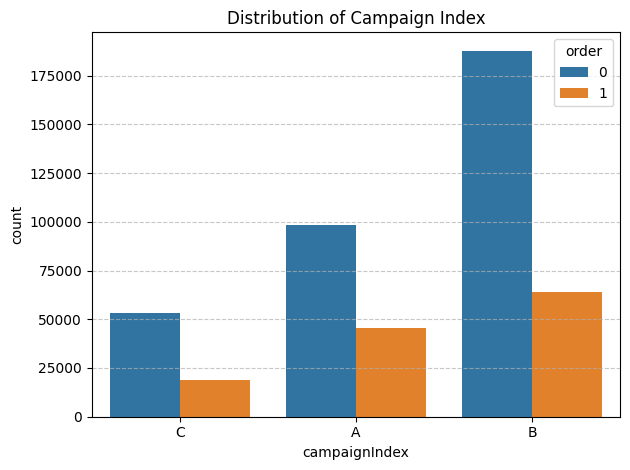

In [28]:
# Distribution of campaign index
# =================================================================================

# Numbers
campaignIndex_counts = df['campaignIndex'].value_counts()
campaignIndex_percentages = (df['campaignIndex'].value_counts(normalize=True) * 100).round(2)
campaignIndex_order_ct = pd.crosstab(df['campaignIndex'], df['order'])
campaignIndex_order_ct_pct = (pd.crosstab(df['campaignIndex'], df['order'], normalize='index') * 100).round(2)
campaignIndex_EDA_df = pd.DataFrame({
    'total_count': campaignIndex_counts,
    'total_percentage': campaignIndex_percentages,
    'order_0_count': campaignIndex_order_ct[0],
    'order_1_count': campaignIndex_order_ct[1],
    'order_0_percentage': campaignIndex_order_ct_pct[0],
    'order_1_percentage': campaignIndex_order_ct_pct[1]
})
print(campaignIndex_EDA_df)
campaignIndex_EDA_df.to_csv('../data/processed/EDA/campaignIndex.csv', index=True)

# Visualization
plot = sns.countplot(x="campaignIndex", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)
plt.title("Distribution of Campaign Index")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().xaxis.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/EDA/campaignIndex.png')
plt.show()

### Numerical Features

#### ***Price***

       total_count  total_percentage  order_0_count  order_1_count  \
price                                                                
0.02             2              0.00              2              0   
0.03             8              0.00              7              1   
0.04             4              0.00              4              0   
0.06             1              0.00              1              0   
0.07            66              0.00             33             33   
0.08           195              0.01            108             87   
0.09            19              0.00             14              5   
0.11             1              0.00              1              0   
0.13            14              0.00             10              4   
0.15            81              0.00             75              6   

       order_0_percentage  order_1_percentage  
price                                          
0.02               100.00                0.00  
0.03           

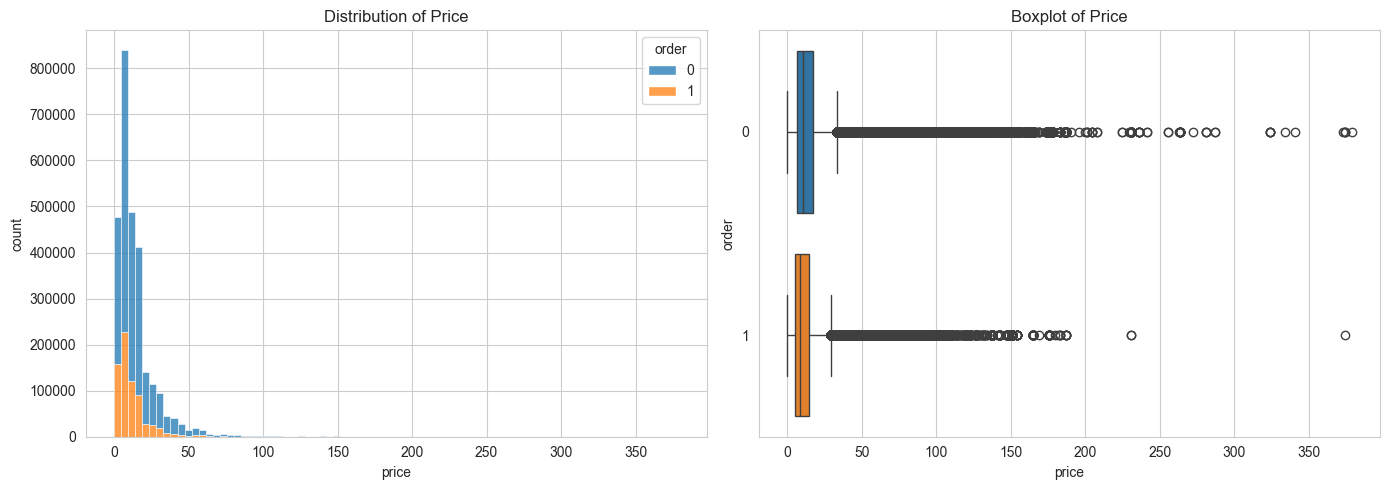

In [37]:
# Distribution of competitor price
# =================================================================================

# Numbers
price_counts = df['price'].value_counts()
price_percentages = (df['price'].value_counts(normalize=True) * 100).round(2)
price_order_ct = pd.crosstab(df['price'], df['order'])
price_order_ct_pct = (pd.crosstab(df['price'], df['order'], normalize='index') * 100).round(2)
price_EDA_df = pd.DataFrame({
    'total_count': price_counts,
    'total_percentage': price_percentages,
    'order_0_count': price_order_ct[0],
    'order_1_count': price_order_ct[1],
    'order_0_percentage': price_order_ct_pct[0],
    'order_1_percentage': price_order_ct_pct[1]
})
print(price_EDA_df.head(10))
price_EDA_df.to_csv('../data/processed/EDA/price.csv', index=True)
print(df['price'].describe().apply('{0:.2f}'.format))

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='price', hue='order', bins=80, multiple='stack', palette='tab10', ax=axes[0])
axes[0].set_title("Distribution of Price")
axes[0].set_xlabel("price")
axes[0].set_ylabel("count")
sns.boxplot(data=df, x='price', y='order', hue='order', palette='tab10', orient='h', ax=axes[1], legend=False)
axes[1].set_title("Boxplot of Price")
plt.tight_layout()
plt.savefig('../data/processed/EDA/price.png')
plt.show()

#### ***Revenue***

         total_count  total_percentage  order_0_count  order_1_count  \
revenue                                                                
0.00         2050913             74.42        2050913              0   
0.07               2              0.00              0              2   
0.08               6              0.00              0              6   
0.14               2              0.00              0              2   
0.16               7              0.00              0              7   
0.18               1              0.00              0              1   
0.21               1              0.00              0              1   
0.24               5              0.00              0              5   
0.25               1              0.00              0              1   
0.26               2              0.00              0              2   

         order_0_percentage  order_1_percentage  
revenue                                          
0.00                  100.0        

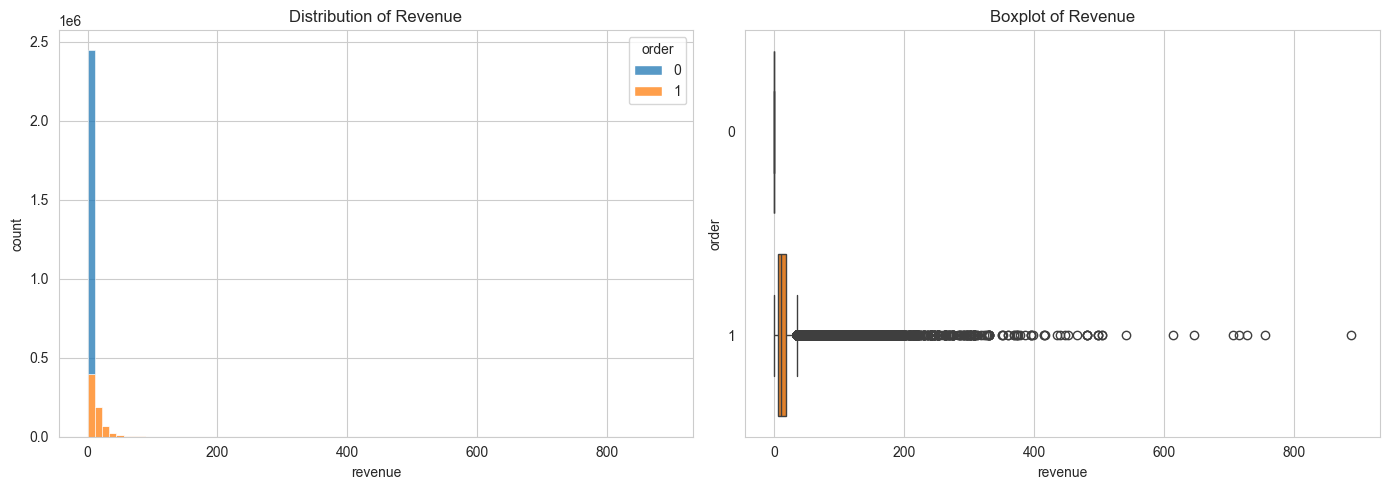

In [38]:
# Distribution of revenue
# =================================================================================

# Numbers
revenue_counts = df['revenue'].value_counts()
revenue_percentages = (df['revenue'].value_counts(normalize=True) * 100).round(2)
revenue_order_ct = pd.crosstab(df['revenue'], df['order'])
revenue_order_ct_pct = (pd.crosstab(df['revenue'], df['order'], normalize='index') * 100).round(2)
revenue_EDA_df = pd.DataFrame({
    'total_count': revenue_counts,
    'total_percentage': revenue_percentages,
    'order_0_count': revenue_order_ct[0],
    'order_1_count': revenue_order_ct[1],
    'order_0_percentage': revenue_order_ct_pct[0],
    'order_1_percentage': revenue_order_ct_pct[1]
})
print(revenue_EDA_df.head(10))
revenue_EDA_df.to_csv('../data/processed/EDA/revenue.csv', index=True)
print(df['revenue'].describe().apply('{0:.2f}'.format))

# Visualization
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='revenue', hue='order', bins=80, multiple='stack', palette='tab10', ax=axes[0])
axes[0].set_title("Distribution of Revenue")
axes[0].set_xlabel("revenue")
axes[0].set_ylabel("count")
sns.boxplot(data=df, x='revenue', y='order', hue='order', palette='tab10', orient='h', ax=axes[1], legend=False)
axes[1].set_title("Boxplot of Revenue")
plt.tight_layout()
plt.savefig('../data/processed/EDA/revenue.png')
plt.show()

#### ***Reference Price***

      total_count  total_percentage  order_0_count  order_1_count  \
rrp                                                                 
0.07          257              0.01            139            118   
0.18            2              0.00              2              0   
0.20           55              0.00             46              9   
0.22           12              0.00             10              2   
0.26          109              0.00            100              9   
0.28           22              0.00             19              3   
0.29           59              0.00             56              3   
0.30          236              0.01            159             77   
0.33           88              0.00             66             22   
0.34          115              0.00             87             28   

      order_0_percentage  order_1_percentage  
rrp                                           
0.07               54.09               45.91  
0.18              100.00      

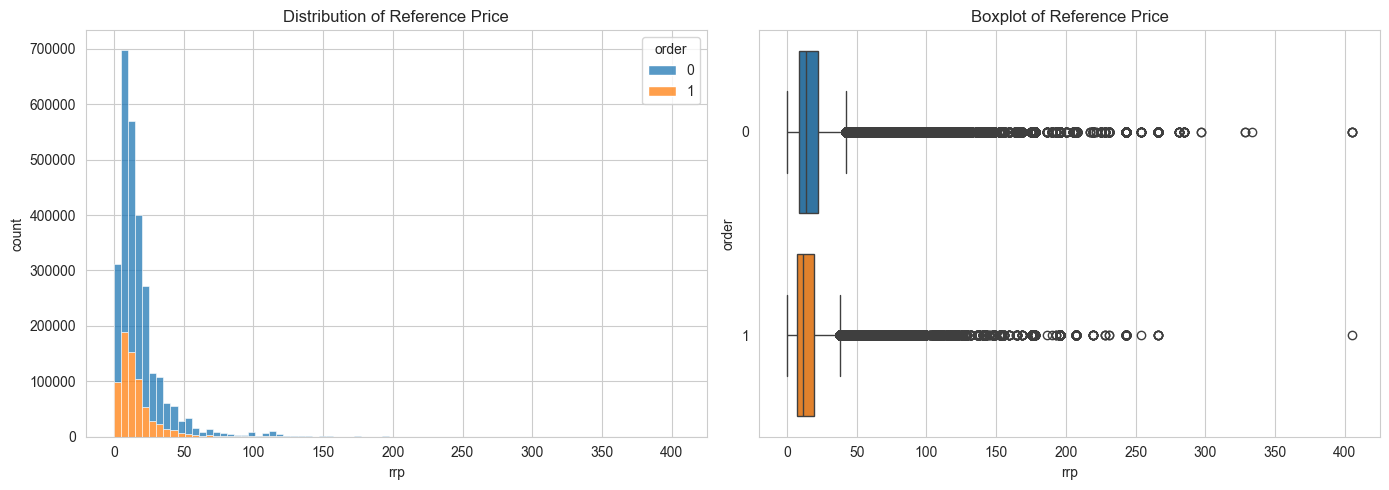

In [39]:
# Distribution of reference price (rrp) 
# =================================================================================

# Numbers
revenue_counts = df['rrp'].value_counts()
revenue_percentages = (df['rrp'].value_counts(normalize=True) * 100).round(2)
revenue_order_ct = pd.crosstab(df['rrp'], df['order'])
revenue_order_ct_pct = (pd.crosstab(df['rrp'], df['order'], normalize='index') * 100).round(2)
revenue_EDA_df = pd.DataFrame({
    'total_count': revenue_counts,
    'total_percentage': revenue_percentages,
    'order_0_count': revenue_order_ct[0],
    'order_1_count': revenue_order_ct[1],
    'order_0_percentage': revenue_order_ct_pct[0],
    'order_1_percentage': revenue_order_ct_pct[1]
})
print(revenue_EDA_df.head(10))
revenue_EDA_df.to_csv('../data/processed/EDA/rrp.csv', index=True)
print(df['rrp'].describe().apply('{0:.2f}'.format))

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='rrp', hue='order', bins=80, multiple='stack', palette='tab10', ax=axes[0])
axes[0].set_title("Distribution of Reference Price")
axes[0].set_xlabel("rrp")
axes[0].set_ylabel("count")
sns.boxplot(data=df, x='rrp', y='order', hue='order', palette='tab10', orient='h', ax=axes[1], legend=False)
axes[1].set_title("Boxplot of Reference Price")
plt.tight_layout()
plt.savefig('../data/processed/EDA/rrp.png')
plt.show()

#### ***Competitor Price***

                 total_count  total_percentage  order_0_count  order_1_count  \
competitorPrice                                                                
0.00                     976              0.04            756            220   
0.07                     146              0.01             76             70   
0.08                      65              0.00             36             29   
0.14                      12              0.00              5              7   
0.17                      11              0.00              7              4   
0.20                       3              0.00              3              0   
0.24                       9              0.00              8              1   
0.25                      88              0.00             82              6   
0.26                      53              0.00             35             18   
0.28                       8              0.00              5              3   

                 order_0_percentage  or

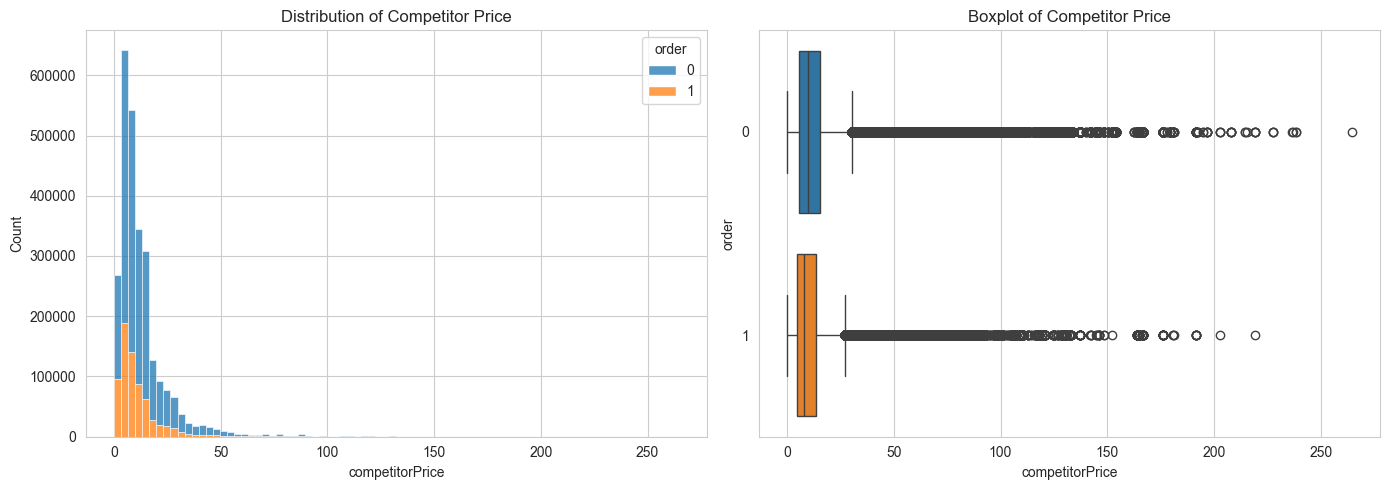

In [36]:
# Distribution of competitor price
# =================================================================================

# Numbers
competitorPrice_counts = df['competitorPrice'].value_counts()
competitorPrice_percentages = (df['competitorPrice'].value_counts(normalize=True) * 100).round(2)
competitorPrice_order_ct = pd.crosstab(df['competitorPrice'], df['order'])
competitorPrice_order_ct_pct = (pd.crosstab(df['competitorPrice'], df['order'], normalize='index') * 100).round(2)
competitorPrice_EDA_df = pd.DataFrame({
    'total_count': competitorPrice_counts,
    'total_percentage': competitorPrice_percentages,
    'order_0_count': competitorPrice_order_ct[0],
    'order_1_count': competitorPrice_order_ct[1],
    'order_0_percentage': competitorPrice_order_ct_pct[0],
    'order_1_percentage': competitorPrice_order_ct_pct[1]
})
print(competitorPrice_EDA_df.head(10))
competitorPrice_EDA_df.to_csv('../data/processed/EDA/competitorPrice.csv', index=True)
print(df['competitorPrice'].describe().apply('{0:.2f}'.format))

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='competitorPrice', hue='order', bins=80, multiple='stack', palette='tab10', ax=axes[0])
axes[0].set_title("Distribution of Competitor Price")
sns.boxplot(data=df, x='competitorPrice', y='order', hue='order', palette='tab10', orient='h', ax=axes[1], legend=False)
axes[1].set_title("Boxplot of Competitor Price")
plt.tight_layout()
plt.savefig('../data/processed/EDA/competitorPrice.png')
plt.show()